# Задание 1. Старт. Загрузка и осмотр данных

## Шаг 0. Настройка среды выполнения
Если вы выполняете задание на локальной машине, перед выполнением задания создайте виртуальную среду, активируйте ее и скачайте библиотеки `pandas`, `numpy`, `matplotlib` и `seaborn`.  

Если вы выполняете задание в colab или kaggle, активируйте среду выполнения.

## Шаг 1. Определение номера варианта и скачивание датасета
Перейдите в Google Таблицу со списком студентов. Найдите свое ФИО в списке и запомните соответствующий порядковый номер (поле № п/п) в первом столбце. Заполните его в ячейке ниже и выполните ячейку. Если вы не можете найти себя в списке, обратитесь к своему преподавателю практики.


In [1]:
Student_ID = 36

Теперь выполните следующую ячейку. Она вычислит номер задания и выведет его.

In [2]:
datasets = [
    ('US Air Carrier market in 2019','https://raw.githubusercontent.com/markpolyak/datasets/refs/heads/main/data/aircarrier_market_us_2019.zip'),
    ('Video Game Sales with Ratings', 'https://www.kaggle.com/datasets/rush4ratio/video-game-sales-with-ratings'),
    ('Medical Cost Personal Dataset', 'https://www.kaggle.com/datasets/mirichoi0218/insurance'),
    ('Netflix Movies and TV Shows', 'https://www.kaggle.com/datasets/shivamb/netflix-shows')
]

dataset_id = None if Student_ID is None else Student_ID % len(datasets)
if dataset_id is None:
    print("ОШИБКА! Не указан порядковый номер студента в списке группы.")
else:
    print(f"Датасет '{datasets[dataset_id][0]}' доступен по следующей ссылке: {datasets[dataset_id][1]}")

Датасет 'US Air Carrier market in 2019' доступен по следующей ссылке: https://raw.githubusercontent.com/markpolyak/datasets/refs/heads/main/data/aircarrier_market_us_2019.zip


**Скачаем датасет**

In [3]:
!wget "https://raw.githubusercontent.com/markpolyak/datasets/refs/heads/main/data/aircarrier_market_us_2019.zip" \
    -O am_data.zip && unzip am_data.zip && rm -r am_data.zip

--2025-10-04 22:16:34--  https://raw.githubusercontent.com/markpolyak/datasets/refs/heads/main/data/aircarrier_market_us_2019.zip
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 198.18.0.123, fc00::7
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|198.18.0.123|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 10159563 (9.7M) [application/zip]
Saving to: ‘am_data.zip’

am_data.zip         100%[===================>]   9.69M  21.9MB/s    in 0.4s    

2025-10-04 22:16:35 (21.9 MB/s) - ‘am_data.zip’ saved [10159563/10159563]

Archive:  am_data.zip
  inflating: aircarrier_market_us_2019.csv  


## Шаг 2. Загрузка данных

Импортируем библиотеки

In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats
from sklearn.cluster import KMeans
import matplotlib.cm as cm

Загрузите датасет в `pandas.DataFrame`, сохраните его в переменной `df`. Проинспектируйте датасет, используя `df.head()`.

In [5]:
df = pd.read_csv("aircarrier_market_us_2019.csv")
df.head()

,PASSENGERS,FREIGHT,MAIL,DISTANCE,UNIQUE_CARRIER,AIRLINE_ID,UNIQUE_CARRIER_NAME,UNIQUE_CARRIER_ENTITY,REGION,CARRIER,...,DEST_STATE_NM,DEST_COUNTRY,DEST_COUNTRY_NAME,DEST_WAC,YEAR,QUARTER,MONTH,DISTANCE_GROUP,CLASS,DATA_SOURCE
0,0.0,53185.0,0.0,8165.0,EK,20392,Emirates,9678A,I,EK,...,Texas,US,United States,74,2019,1,3,17,G,IF
1,0.0,9002.0,0.0,6849.0,EK,20392,Emirates,9678A,I,EK,...,New York,US,United States,22,2019,1,3,14,G,IF
2,0.0,2220750.0,0.0,7247.0,EK,20392,Emirates,9678A,I,EK,...,Illinois,US,United States,41,2019,1,3,15,G,IF
3,0.0,1201490.0,0.0,8165.0,EK,20392,Emirates,9678A,I,EK,...,NaN,AE,United Arab Emirates,678,2019,1,3,17,G,IF
4,0.0,248642.0,0.0,6849.0,EK,20392,Emirates,9678A,I,EK,...,NaN,AE,United Arab Emirates,678,2019,1,3,14,G,IF


Сконвертируйте названия столбцов в нижний регистр, после этого создайте переменную `columns` и сохраните в нее список столбцов.

In [6]:
df = df.rename(str.lower, axis='columns')
columns = df.columns
for col in columns:
    print(col)

passengers
freight
mail
distance
unique_carrier
airline_id
unique_carrier_name
unique_carrier_entity
region
carrier
carrier_name
carrier_group
carrier_group_new
origin_airport_id
origin_airport_seq_id
origin_city_market_id
origin
origin_city_name
origin_state_abr
origin_state_fips
origin_state_nm
origin_country
origin_country_name
origin_wac
dest_airport_id
dest_airport_seq_id
dest_city_market_id
dest
dest_city_name
dest_state_abr
dest_state_fips
dest_state_nm
dest_country
dest_country_name
dest_wac
year
quarter
month
distance_group
class
data_source


При желании, выведите информацию о датафрейме с помощью функции `.info()`

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321409 entries, 0 to 321408
Data columns (total 41 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   passengers             321409 non-null  float64
 1   freight                321409 non-null  float64
 2   mail                   321409 non-null  float64
 3   distance               321409 non-null  float64
 4   unique_carrier         321409 non-null  object 
 5   airline_id             321409 non-null  int64  
 6   unique_carrier_name    321409 non-null  object 
 7   unique_carrier_entity  321409 non-null  object 
 8   region                 321409 non-null  object 
 9   carrier                321409 non-null  object 
 10  carrier_name           321409 non-null  object 
 11  carrier_group          321409 non-null  int64  
 12  carrier_group_new      321409 non-null  int64  
 13  origin_airport_id      321409 non-null  int64  
 14  origin_airport_seq_id  321409 non-nu

## Шаг 3. Анализ датафрейма


Проверьте, есть ли в данном датасете пропущенные значения? Удалите из датафрейма **объекты** с пропущенными значениями.

**ВАЖНО**: не перезаписывайте исходную переменную `df`, вместо этого сохраните новый датафрейм в переменную `df_dropna`

In [8]:
df_dropna = df.dropna()
df_dropna.count()

passengers               252114
freight                  252114
mail                     252114
distance                 252114
unique_carrier           252114
airline_id               252114
unique_carrier_name      252114
unique_carrier_entity    252114
region                   252114
carrier                  252114
carrier_name             252114
carrier_group            252114
carrier_group_new        252114
origin_airport_id        252114
origin_airport_seq_id    252114
origin_city_market_id    252114
origin                   252114
origin_city_name         252114
origin_state_abr         252114
origin_state_fips        252114
origin_state_nm          252114
origin_country           252114
origin_country_name      252114
origin_wac               252114
dest_airport_id          252114
dest_airport_seq_id      252114
dest_city_market_id      252114
dest                     252114
dest_city_name           252114
dest_state_abr           252114
dest_state_fips          252114
dest_sta

Сгенерируйте статистики по вашему датасету. Подсказка: для этого у датафрейма есть встренная функция `.describe()`.

In [9]:
df.describe()

,passengers,freight,mail,distance,airline_id,carrier_group,carrier_group_new,origin_airport_id,origin_airport_seq_id,origin_city_market_id,...,origin_wac,dest_airport_id,dest_airport_seq_id,dest_city_market_id,dest_state_fips,dest_wac,year,quarter,month,distance_group
count,321409.000000,3.214090e+05,3.214090e+05,321409.000000,321409.000000,321409.000000,321409.000000,321409.000000,3.214090e+05,321409.000000,...,321409.000000,321409.000000,3.214090e+05,321409.000000,286383.000000,321409.000000,321409.0,321409.000000,321409.000000,321409.000000
mean,3286.160481,1.450763e+05,4.247738e+03,1237.749316,20198.023518,2.199801,2.864780,12842.043925,1.284208e+06,32144.330566,...,93.779583,12843.681593,1.284372e+06,32146.834662,25.205588,94.874509,2019.0,2.523787,6.582314,3.013310
std,6429.211206,7.597226e+05,4.012657e+04,1473.507865,572.063019,1.060932,1.423798,1618.002736,1.618002e+05,1540.325153,...,166.630355,1616.482306,1.616481e+05,1540.562159,17.880442,167.859405,0.0,1.122262,3.473409,2.926968
min,0.000000,0.000000e+00,0.000000e+00,0.000000,19393.000000,0.000000,0.000000,10005.000000,1.000501e+06,30005.000000,...,1.000000,10005.000000,1.000501e+06,30003.000000,1.000000,1.000000,2019.0,1.000000,1.000000,1.000000
25%,6.000000,0.000000e+00,0.000000e+00,339.000000,19805.000000,1.000000,2.000000,11298.000000,1.129806e+06,30852.000000,...,33.000000,11298.000000,1.129806e+06,30852.000000,8.000000,33.000000,2019.0,2.000000,4.000000,1.000000
50%,656.000000,0.000000e+00,0.000000e+00,771.000000,20304.000000,3.000000,3.000000,12892.000000,1.289208e+06,31703.000000,...,45.000000,12892.000000,1.289208e+06,31703.000000,24.000000,45.000000,2019.0,3.000000,7.000000,2.000000
75%,3962.000000,5.703000e+03,0.000000e+00,1476.000000,20409.000000,3.000000,3.000000,14107.000000,1.410702e+06,33198.000000,...,85.000000,14107.000000,1.410702e+06,33198.000000,41.000000,85.000000,2019.0,4.000000,10.000000,3.000000
max,97644.000000,1.050779e+08,6.530776e+06,10362.000000,22062.000000,3.000000,9.000000,16876.000000,1.687601e+06,36843.000000,...,975.000000,16876.000000,1.687601e+06,36843.000000,78.000000,961.000000,2019.0,4.000000,12.000000,21.000000


Данные у нас за один год, так что смело удалим этот столбец из таблицы, чтобы он нам не мешал.

In [10]:
df = df.drop("year", axis=1)
df_dropna = df_dropna.drop("year", axis=1)
columns = df.columns

### Дополнительное задание *. Заполните пропуски в датасете

Для того, чтобы заполнить пропуски, используйте моды для соответствующего категориального признака и медианное значение для числового, если такие есть. Например, если в столбце `A` есть несколько пропусков, найдите моду столбца `A_dropna` (очищенного от пропусков) и заполните ею все остальные пропуски.

**ВАЖНО**: Дополнительное задание не является обязательным к выполнению, но позволяет получить дополнительные баллы по курсу.

In [11]:
df_fillna = pd.DataFrame({col : df[col].fillna(df_dropna[col].mode()[0]) for  col in columns})
df_fillna.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 321409 entries, 0 to 321408
Data columns (total 40 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   passengers             321409 non-null  float64
 1   freight                321409 non-null  float64
 2   mail                   321409 non-null  float64
 3   distance               321409 non-null  float64
 4   unique_carrier         321409 non-null  object 
 5   airline_id             321409 non-null  int64  
 6   unique_carrier_name    321409 non-null  object 
 7   unique_carrier_entity  321409 non-null  object 
 8   region                 321409 non-null  object 
 9   carrier                321409 non-null  object 
 10  carrier_name           321409 non-null  object 
 11  carrier_group          321409 non-null  int64  
 12  carrier_group_new      321409 non-null  int64  
 13  origin_airport_id      321409 non-null  int64  
 14  origin_airport_seq_id  321409 non-nu

# Задание 2. Работа с числовыми признаками

## Шаг 1. Отбор числовых признаков

Определите числовые признаки датасета. Запишите их названия в список `numeric_features`. После этого, отделите от датафрейма часть со всеми числовыми признаками.

**ВАЖНО**: Не перезаписывайте `df_dropna`, вместо этого запишите полученный датафрейм в переменную `df_numeric`.


In [12]:
df_numeric = df_dropna.select_dtypes(include='number')
numeric_features = df_numeric.columns.to_list()
for nf in numeric_features:
    print(nf)

passengers
freight
mail
distance
airline_id
carrier_group
carrier_group_new
origin_airport_id
origin_airport_seq_id
origin_city_market_id
origin_state_fips
origin_wac
dest_airport_id
dest_airport_seq_id
dest_city_market_id
dest_state_fips
dest_wac
quarter
month
distance_group


## Шаг 2. Визуализация распределений

Для каждого числового признака визуализируйте его распределение, используя гистограммы. Для наглядности, поместите название признака в заголовок гистограммы.

Подсказка: вы можете использовать `plt.subplots` для размещения нескольких визуализаций на одной фигуре.

In [13]:
print(len(numeric_features))

20


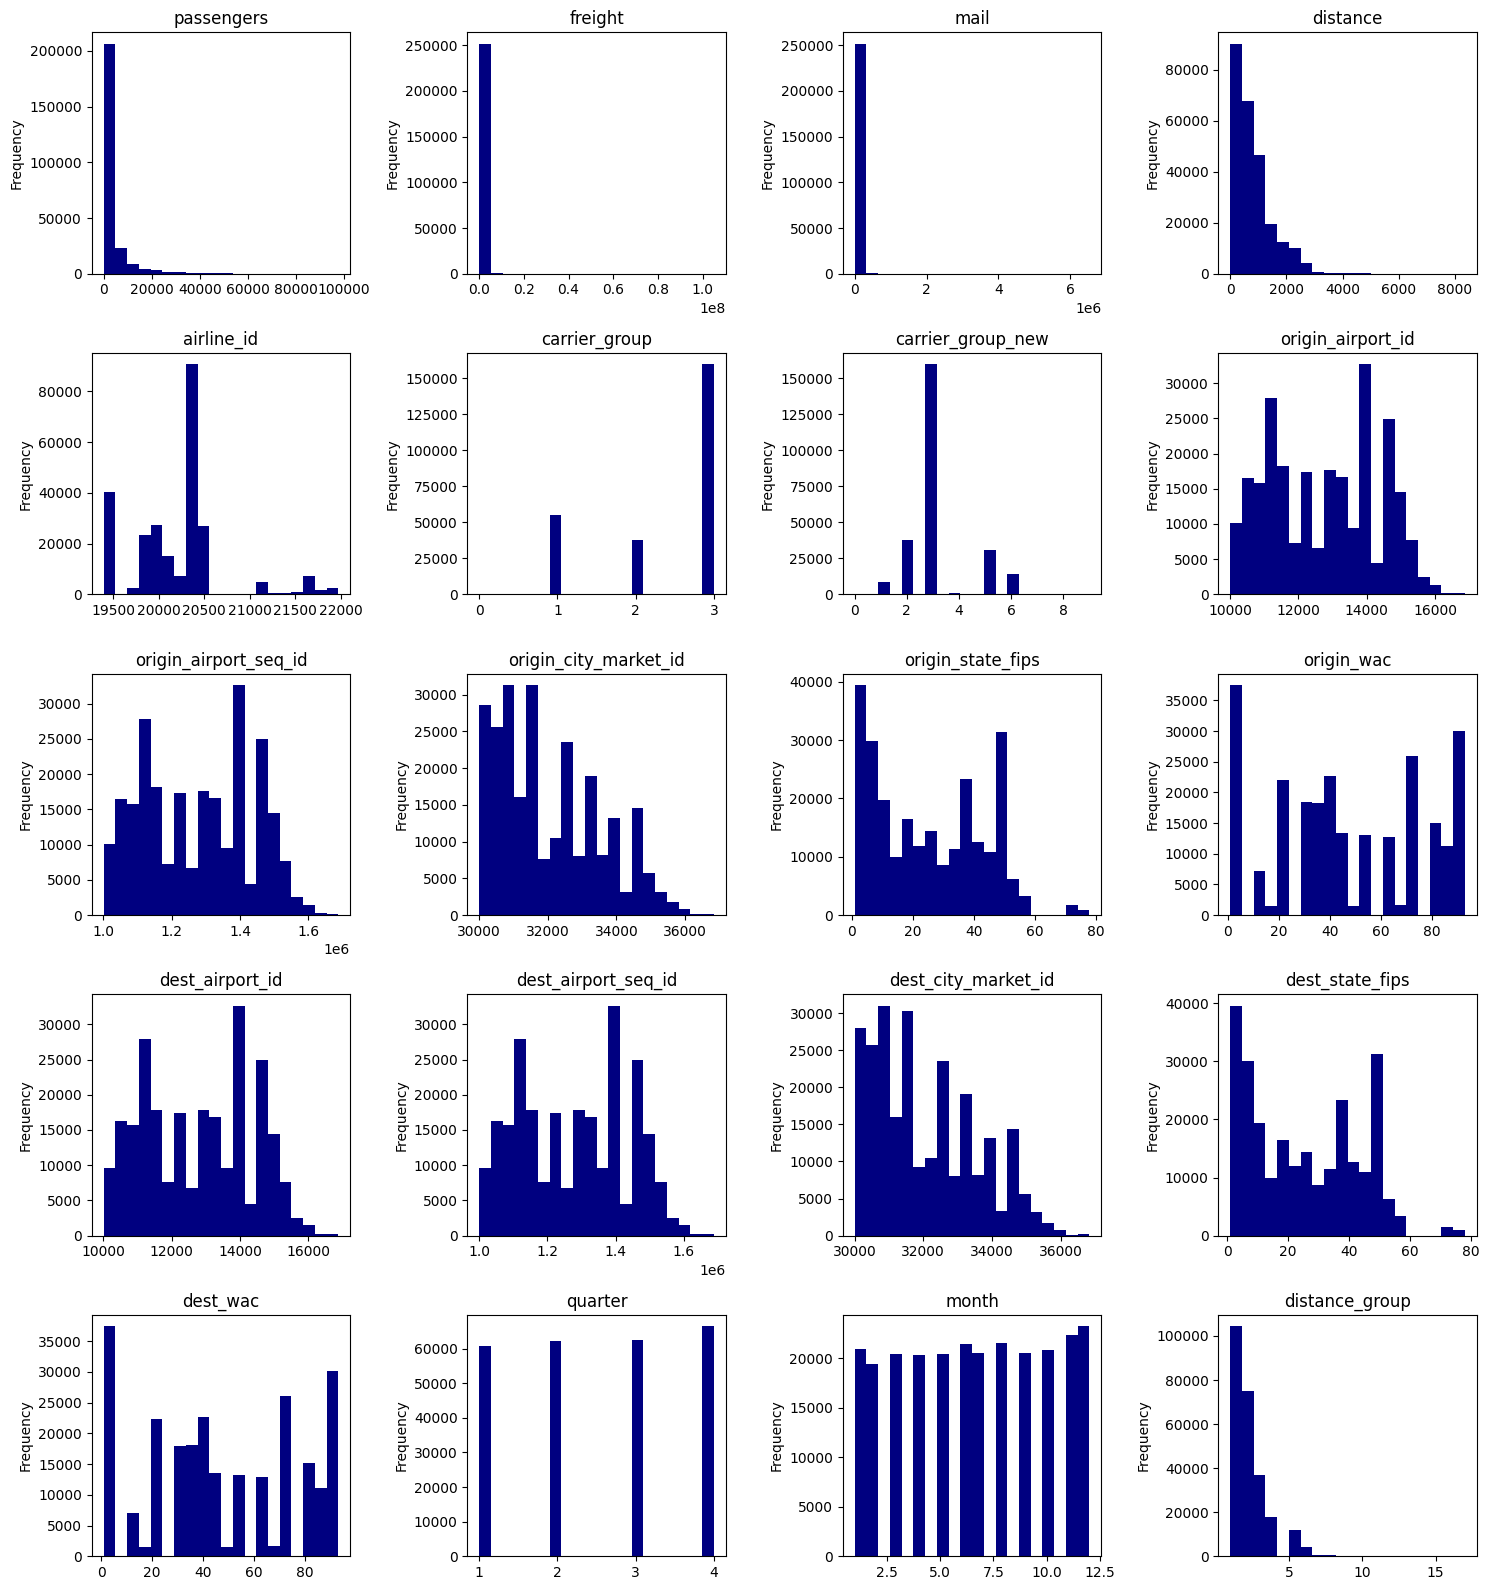

In [14]:
fig, axes = plt.subplots(5, 4, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    df_numeric[col].plot(kind='hist', bins=20, ax=axes[i], title=col, color="navy")

plt.tight_layout()
plt.show()

## Шаг 3. Поиск корреляции между числовыми признаками

Вычислите корреляции по Пирсону и по Спирмену между всеми парами числовых признаков. Подумайте, в чем между ними разница?

Формула корреляции Пирсона:
$$
r_{xy} = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sqrt{\sum_{i=1}^{n}(x_i - \bar{x})^2 \sum_{i=1}^{n}(y_i - \bar{y})^2}},
$$
где $\overline{x}, \overline{y}$ - выборочные средние выборок $x$ и $y$. $r_{xy}$ принимает значения в диапазоне $[-1, 1]$.

Формула корреляции Спирмена:
$$
\rho = \frac{V_x + V_y - \sum_{i=1}^{n} \left(R(x_i) - R(y_i)\right)^2}{2 \sqrt{V_x \, V_y}},
$$,
где

$$
V_x = \frac{n(n^2-1)}{12} - T_x, 
\qquad 
V_y = \frac{n(n^2-1)}{12} - T_y,
$$

$$
T_x = \frac{1}{12} \sum_j \left(m_{x,j}^3 - m_{x,j}\right), 
\qquad
T_y = \frac{1}{12} \sum_j \left(m_{y,j}^3 - m_{y,j}\right),
$$

а $(m_{x,j}, m_{y,j})$ — размеры групп одинаковых значений в выборках \(x\) и \(y\).

$R(a_i)$ - ранг наблюдения $a_i$ в выборке $a$. Ранг - порядковый номер наблюдения в вариационном ряду соответствующей выборки.

Коэффциент $\rho$ принимает значения в диапазоне $[-1, 1]$. Где $\rho=1$ - обозначает прямую линейную зависимость, а $\rho=-1$ - обратная.

Коэффициент корреляции Пирсона плохо устойчив к выбросам, и лучше применять к выборкам с предположительно линейной зависимостью. Спирмена можно применять к монотонным, но нелинейным зависимостям в том числе.

In [15]:
def pearson_correlation(x, y):
    x, y = np.array(x), np.array(y)
    mean_x, mean_y = np.mean(x), np.mean(y)
    denominator = np.sqrt(np.sum((x - mean_x)**2) * np.sum((y - mean_y)**2))
    if denominator == 0:
        return 0
    return np.sum((x - mean_x) * (y - mean_y)) / denominator

def tie_correction(values):
    _, counts = np.unique(values, return_counts=True)
    m = counts[counts > 1]
    if m.size == 0:
        return 0.0
    return np.sum(m**3 - m) / 12.0

def spearman_correlation(x, y):
    x, y = np.asarray(x), np.asarray(y)
    n = x.size
    rx, ry = stats.rankdata(x, method="average"), stats.rankdata(y, method="average")

    d2_sum = np.sum((rx - ry) ** 2)

    Tx = tie_correction(x)
    Ty = tie_correction(y)
    Vx = n * (n**2 - 1) / 12.0 - Tx
    Vy = n * (n**2 - 1) / 12.0 - Ty

    if Vx <= 0 or Vy <= 0:
        return np.nan

    return (Vx + Vy - d2_sum) / (2.0 * np.sqrt(Vx * Vy))

pearson_matrix = pd.DataFrame(np.eye(len(numeric_features)), 
    index=numeric_features, columns=numeric_features)

spearman_matrix = pd.DataFrame(np.eye(len(numeric_features)), 
    index=numeric_features, columns=numeric_features)

corrs = [pearson_matrix, spearman_matrix] # Для теста) (в данном подходе переменная с таким именем не нужна)

for i, col1 in enumerate(numeric_features):
    for j, col2 in enumerate(numeric_features):
        if i == j:
            continue
        elif i < j:
            pearson_val = pearson_correlation(df_numeric[col1], df_numeric[col2])
            spearman_val = spearman_correlation(df_numeric[col1], df_numeric[col2])
            
            pearson_matrix.loc[col1, col2] = pearson_val
            pearson_matrix.loc[col2, col1] = pearson_val
            
            spearman_matrix.loc[col1, col2] = spearman_val
            spearman_matrix.loc[col2, col1] = spearman_val

Для корреляций признаков по Пирсону постройте тепловую карту от -1 до 1, с центром в 0. Запишите название признака для каждой строки и каждого столбца.

Подсказка: вы можете использовать `seaborn.heatmap()`.

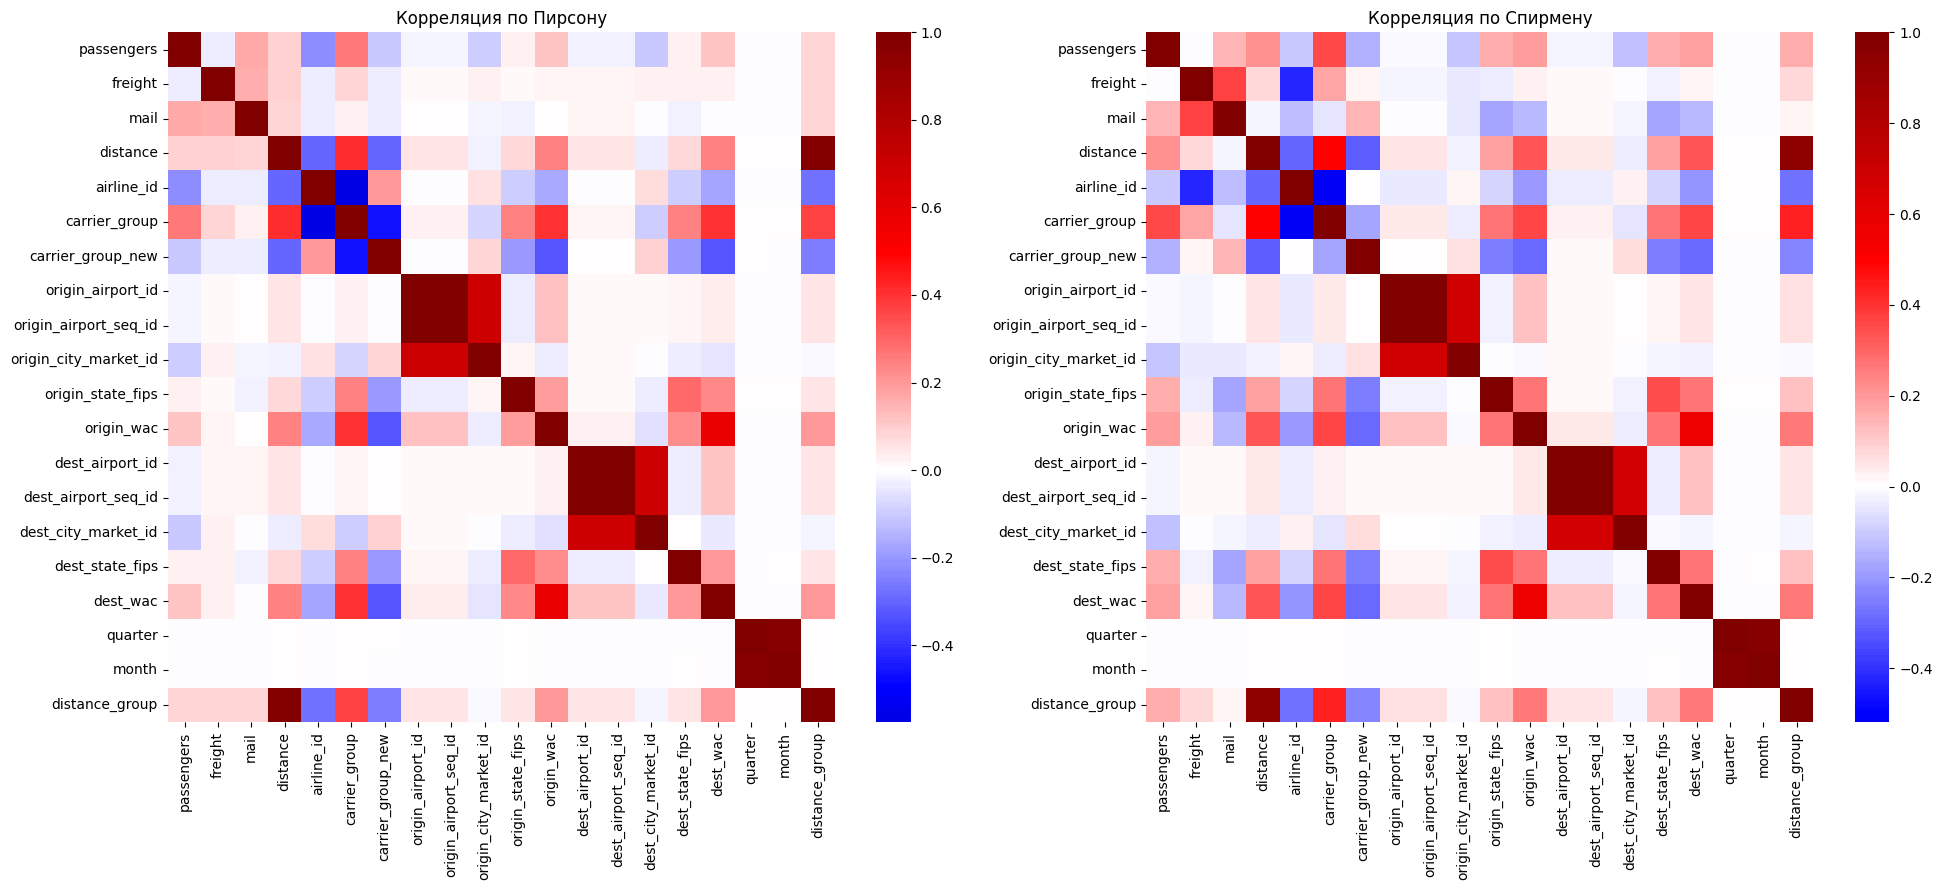

In [16]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 9))
sns.heatmap(pearson_matrix, ax=ax1, annot=False, cmap='seismic', center=0)
ax1.set_title('Корреляция по Пирсону')

sns.heatmap(spearman_matrix, ax=ax2, annot=False, cmap='seismic', center=0)
ax2.set_title('Корреляция по Спирмену')

plt.tight_layout()
plt.show()

Видим, что они весьма похожи. Почему бы не вычесть одну тепловую карту из другой и посмотреть где у нас больше всего отличий?

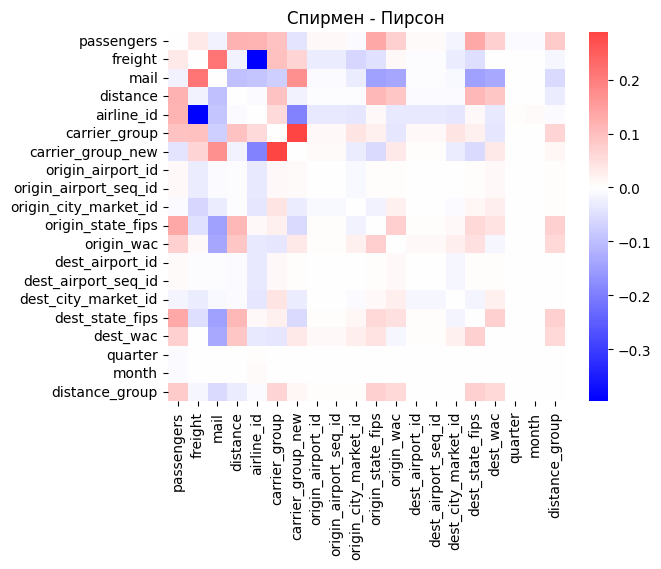

In [17]:
difference_matrix = spearman_matrix - pearson_matrix

sns.heatmap(difference_matrix, annot=False, cmap='bwr', center=0)
plt.title("Спирмен - Пирсон")
plt.show()

Методы по разному оценивают корреляционные связи, но там, где они сильнее - методы выдают более схожие значения. Где корреляция уходит в минус, методы различаеются немного сильнее. Мы видим такой результат, в частности, потому что некоторые зависимости в нашей выборке могут быть нелинейными.

## Шаг 4. Вычисление статистик

Для каждого числового признака вычислите среднее, медиану и стандартное отклонение.

Результаты запишите в соответствующие словари `means`, `medians` и `stds`, в которых ключ (`key`) - название признака (как он записан в датафрейме), значение (`value`) - статистика.

In [18]:
means = {feature : df_numeric[feature].mean() for feature in numeric_features}
medians = {feature : df_numeric[feature].median() for feature in numeric_features}
stds = {feature : df_numeric[feature].std() for feature in numeric_features}

print(f"{'Feature':<25} | {'Mean':>10} | {'Median':>18} | {'Std':>10}")
print("_" * 72)
for feature in numeric_features:
    print(f"{feature:<25} | {df_numeric[feature].mean():>10.2f} | \
        {df_numeric[feature].median():>10.2f} | {df_numeric[feature].std():>10.2f}")

Feature                   |       Mean |             Median |        Std
________________________________________________________________________
passengers                |    3228.26 |             350.00 |    6817.44
freight                   |  100795.12 |               0.00 |  693083.14
mail                      |    4593.00 |               0.00 |   43728.16
distance                  |     789.56 |             619.00 |     680.12
airline_id                |   20180.00 |           20304.00 |     532.01
carrier_group             |       2.41 |               3.00 |       0.83
carrier_group_new         |       3.21 |               3.00 |       1.14
origin_airport_id         |   12765.28 |           12889.00 |    1587.93
origin_airport_seq_id     | 1276531.31 |         1288903.00 |  158793.08
origin_city_market_id     |   32058.99 |           31703.00 |    1488.08
origin_state_fips         |      25.14 |              24.00 |      17.95
origin_wac                |      47.34 |           

## Шаг 5. Стандартизация признаков

Выполните стандартизацию для каждого числового признака:

$$
z = \dfrac{x - \mu}{\sigma}
$$

где $\mu$ - среднее по признаку, $\sigma$ - стандартное отклонение

In [19]:
df_standart = pd.DataFrame({feature : ((df_numeric[feature] - means[feature]) / stds[feature] if stds[feature] else 0) \
    for feature in numeric_features})

print(f"{'Feature':<25} | {'Mean':>10} | {'Median':>18} | {'Std':>10}")
print("_" * 72)
for feature in numeric_features:
    print(f"{feature:<25} | {df_standart[feature].mean():>10.2f} | \
        {df_standart[feature].median():>10.2f} | {df_standart[feature].std():>10.2f}")

Feature                   |       Mean |             Median |        Std
________________________________________________________________________
passengers                |      -0.00 |              -0.42 |       1.00
freight                   |       0.00 |              -0.15 |       1.00
mail                      |       0.00 |              -0.11 |       1.00
distance                  |       0.00 |              -0.25 |       1.00
airline_id                |       0.00 |               0.23 |       1.00
carrier_group             |       0.00 |               0.71 |       1.00
carrier_group_new         |       0.00 |              -0.18 |       1.00
origin_airport_id         |       0.00 |               0.08 |       1.00
origin_airport_seq_id     |      -0.00 |               0.08 |       1.00
origin_city_market_id     |       0.00 |              -0.24 |       1.00
origin_state_fips         |      -0.00 |              -0.06 |       1.00
origin_wac                |       0.00 |           

Подсказка: используйте статистики из предыдущего задания

Повторите шаг 2 этого задания для полученного датафрейма: визуализируйте. Сравните с результатом, полученным ранее.

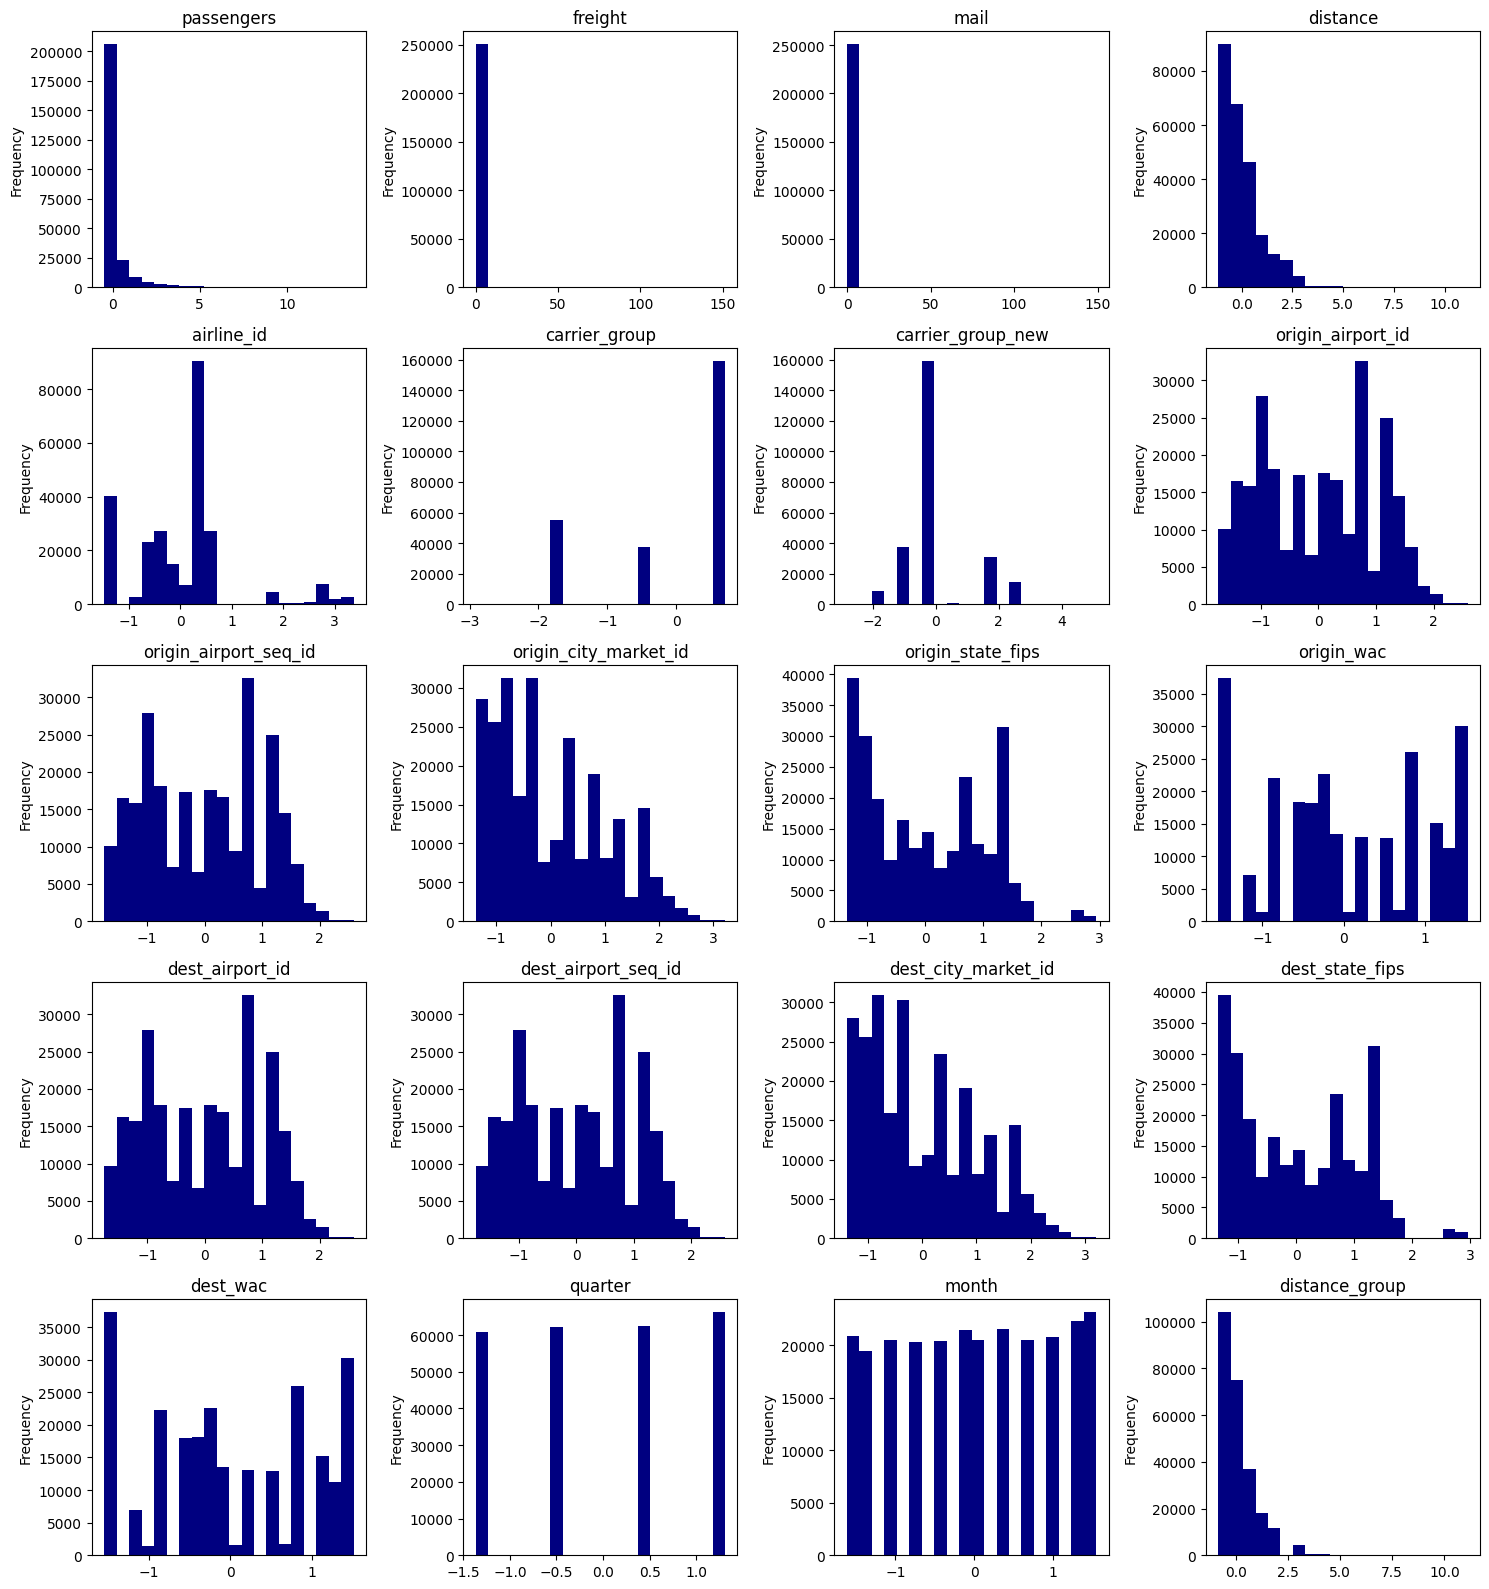

In [20]:
fig, axes = plt.subplots(5, 4, figsize=(15, 16))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    df_standart[col].plot(kind='hist', bins=20, ax=axes[i], title=col, color="navy")

plt.tight_layout()
plt.show()

### Сравнение
Стандартизация нужна для того, чтобы привести данные к нормальному распределению, насколько это возможно. В нашем случае, видим, что диапазоны значений поменялись, но форма распределения не сильно изменилась - нам попались распределения, которые труно сделать очень похожими на нормальное таким способом.

# Задание 3. Работа с категориальными признаками

## Шаг 1. Отбор категориальных признаков

Определите категориальные признаки датасета. Запишите их названия в список `cat_features`. После этого, отделите от датафрейма часть со всеми категориальными признаками.

**ВАЖНО**: Не перезаписывайте `df_dropna`, вместо этого запишите полученный датафрейм в переменную `df_cat`.

In [21]:
df_cat = df_dropna.select_dtypes(include='object')
cat_features = df_cat.columns.to_list()
for feature in cat_features:
    print(feature)

unique_carrier
unique_carrier_name
unique_carrier_entity
region
carrier
carrier_name
origin
origin_city_name
origin_state_abr
origin_state_nm
origin_country
origin_country_name
dest
dest_city_name
dest_state_abr
dest_state_nm
dest_country
dest_country_name
class
data_source


## Шаг 2. Визуализация распределений категориальных признаков

Для каждого категориального признака визуализируйте его распределение. Используйте круговую диаграмму (`plt.pie`). Для каждой диаграммы выведите легенду (с указанием категории) и запишите в заголовок имя признака.

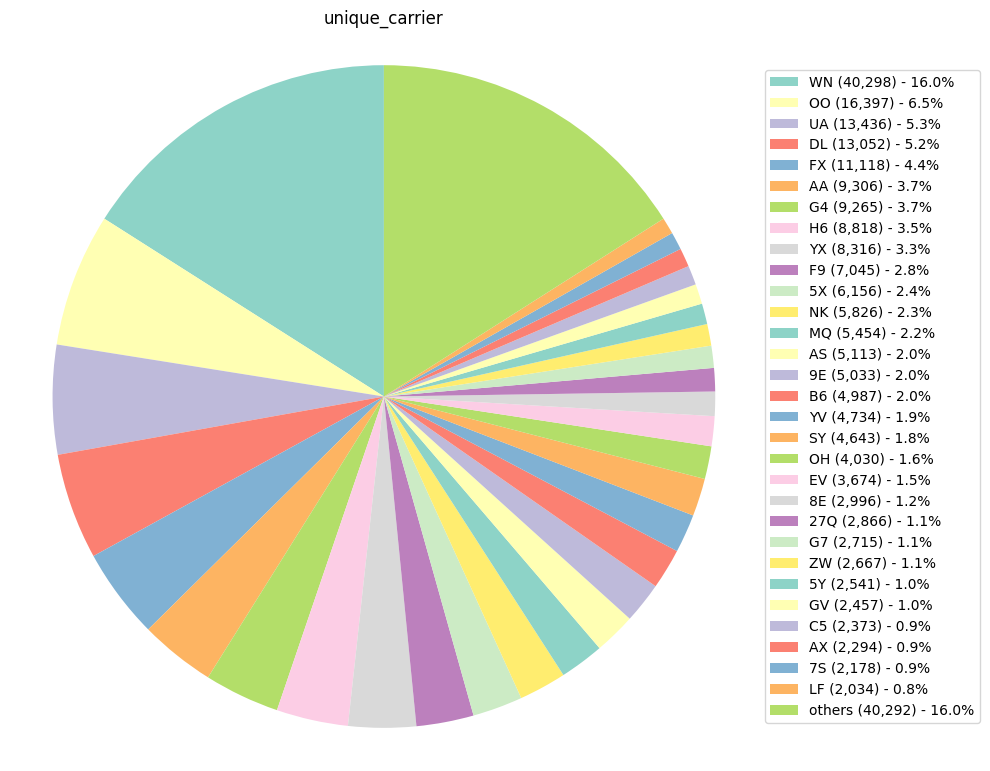

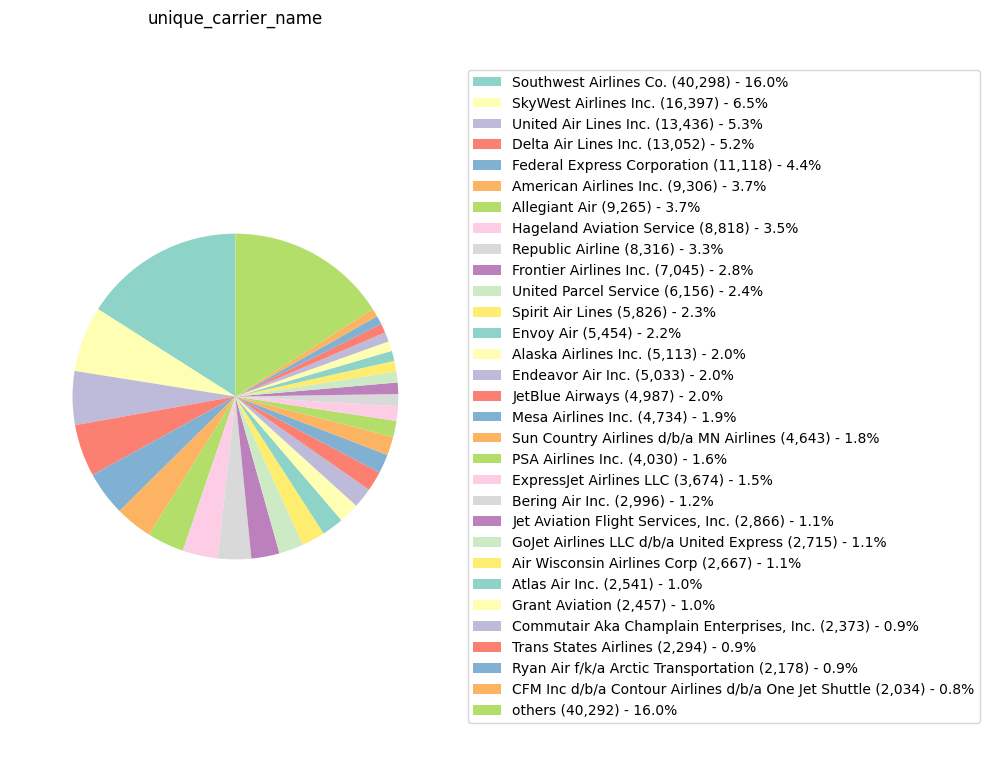

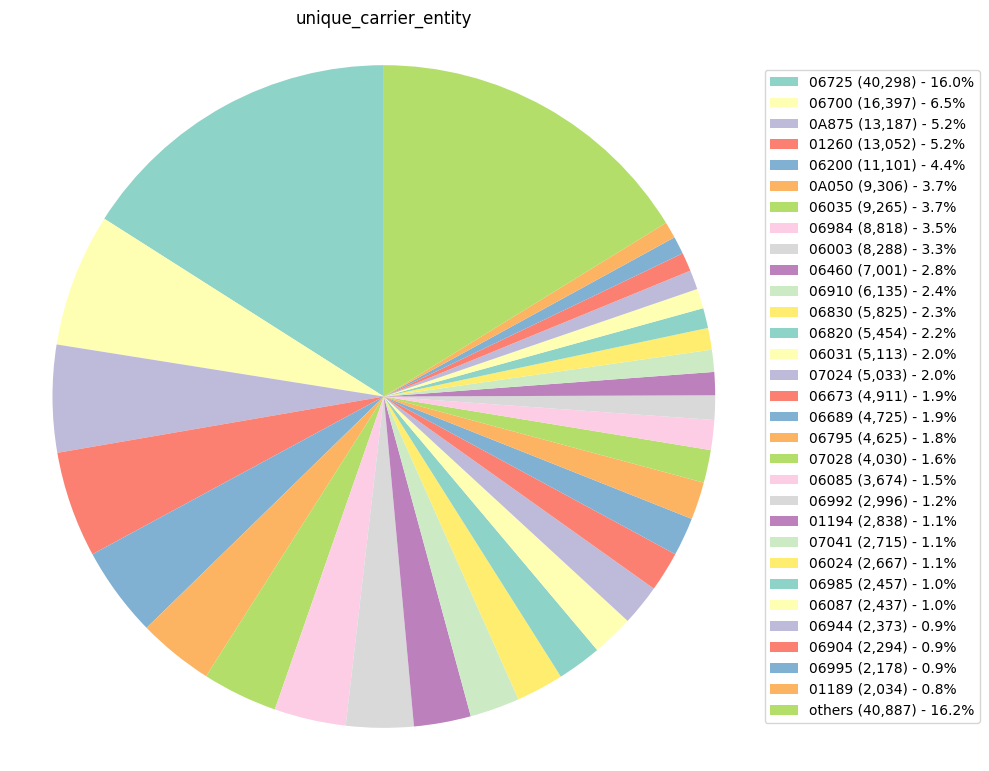

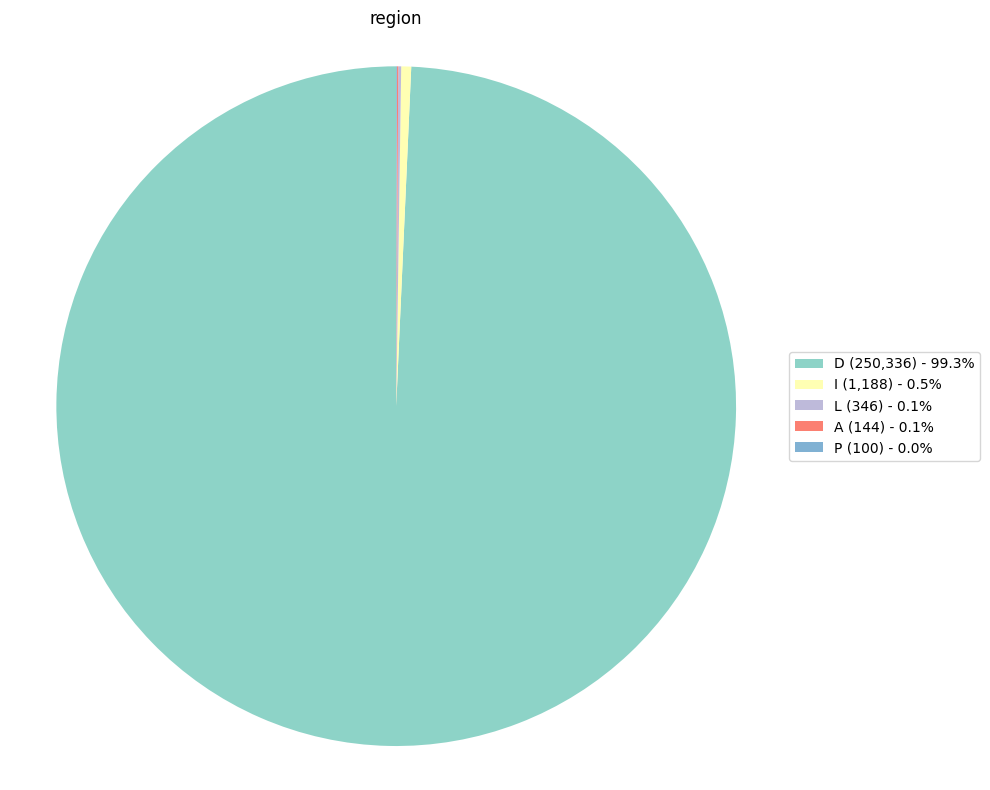

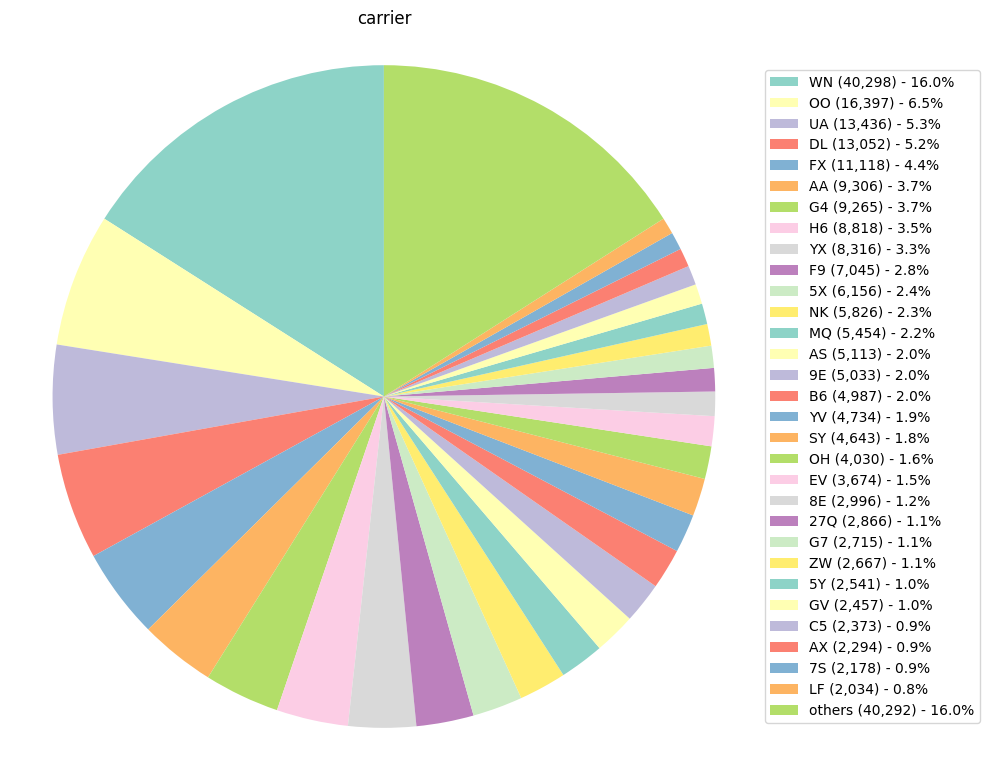

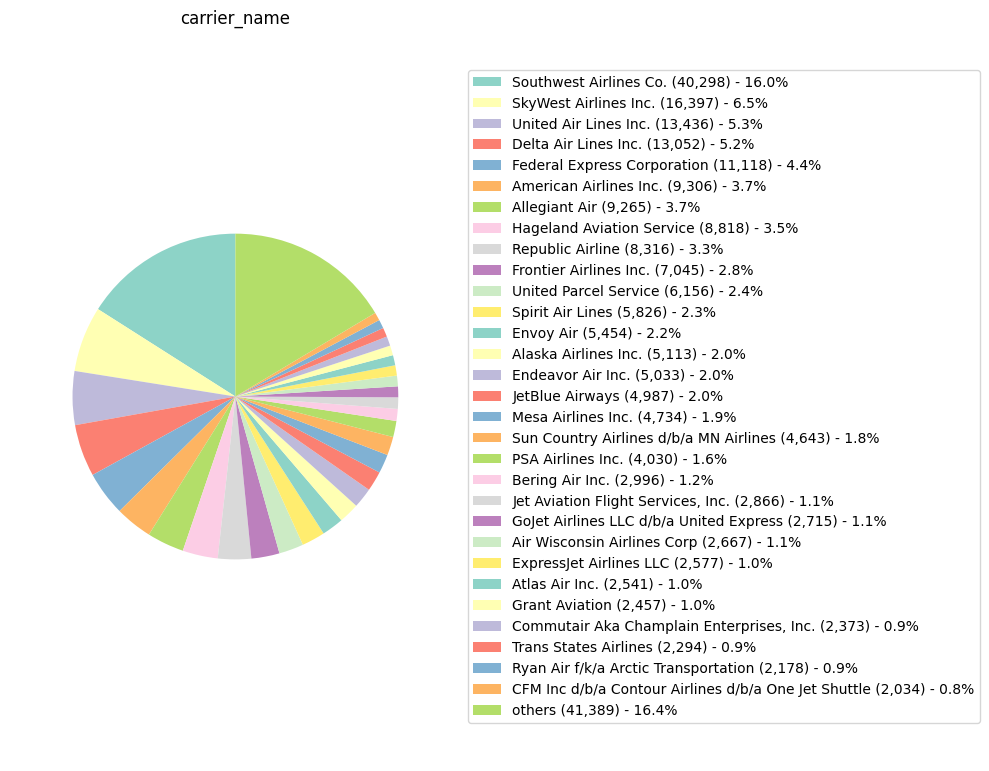

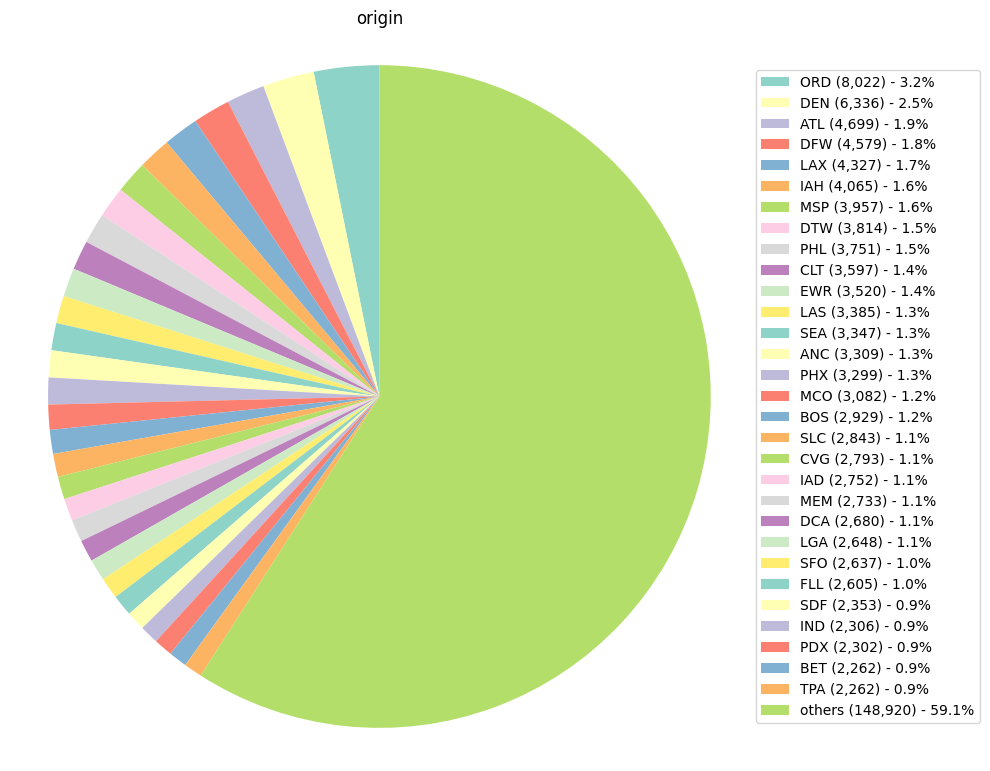

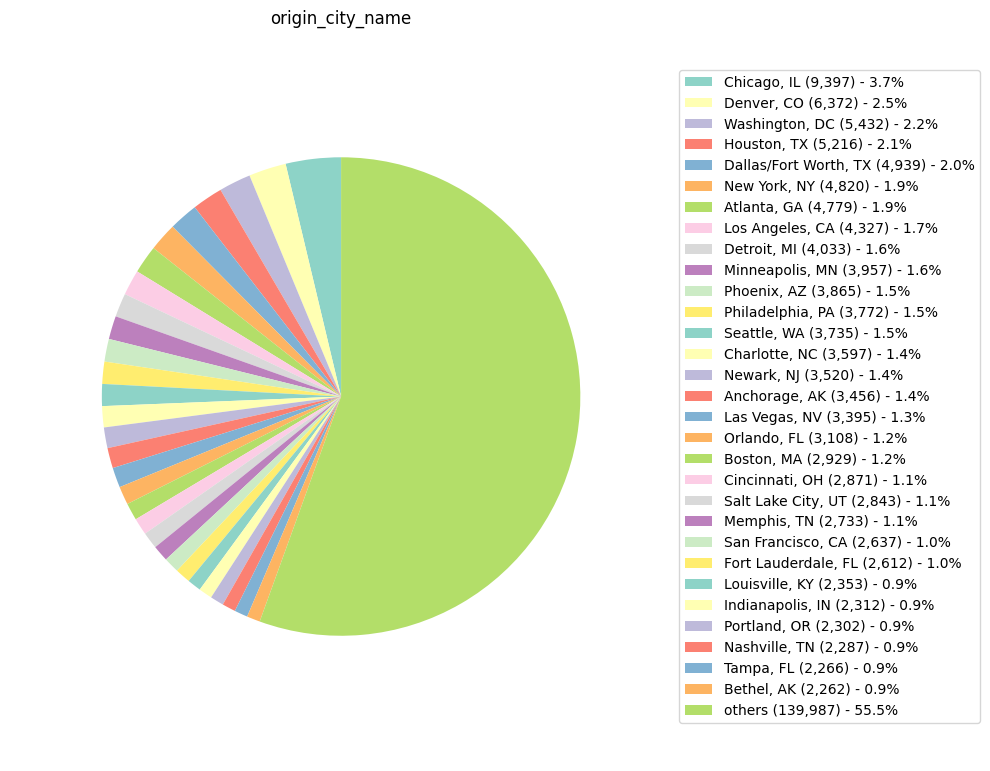

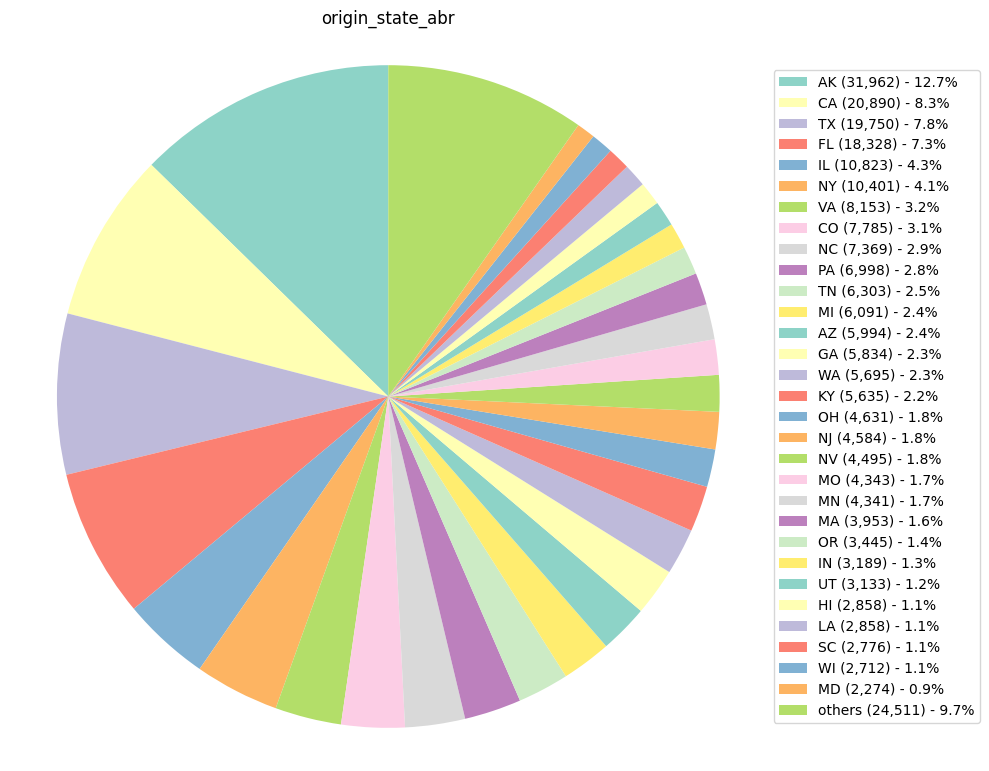

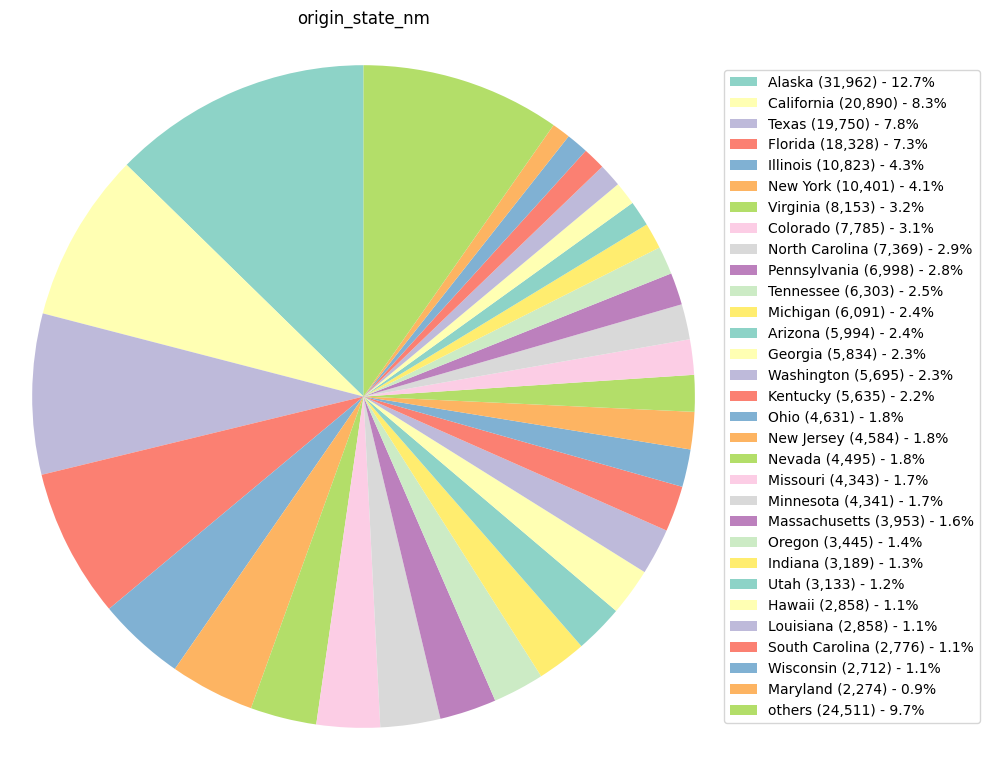

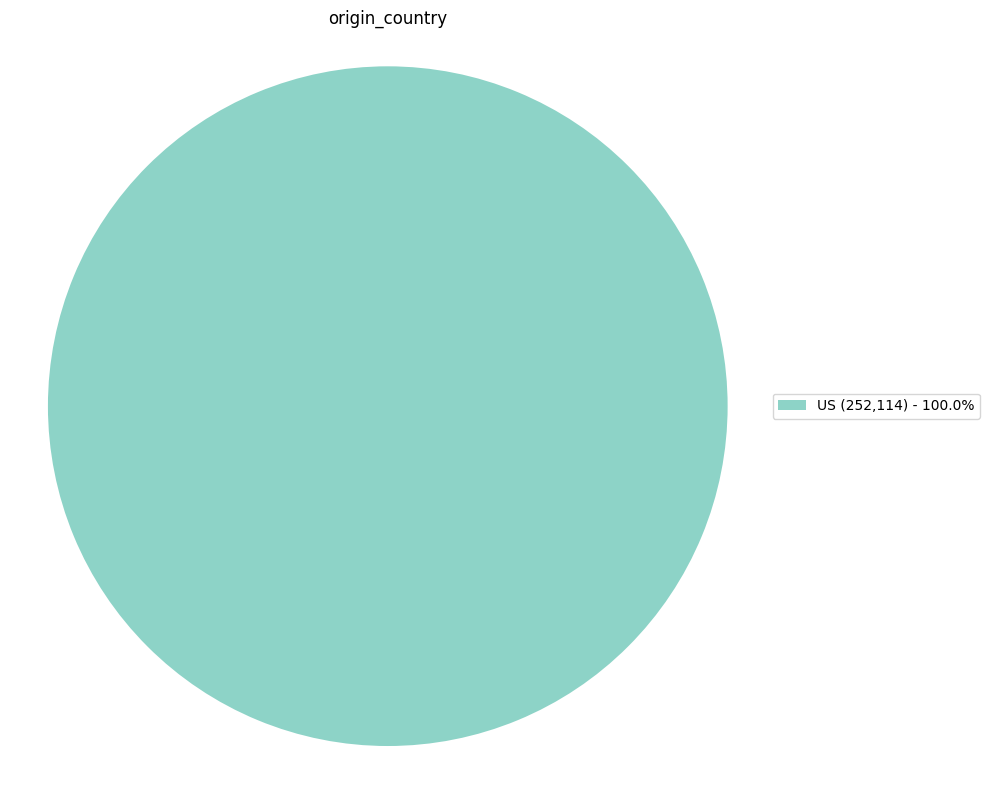

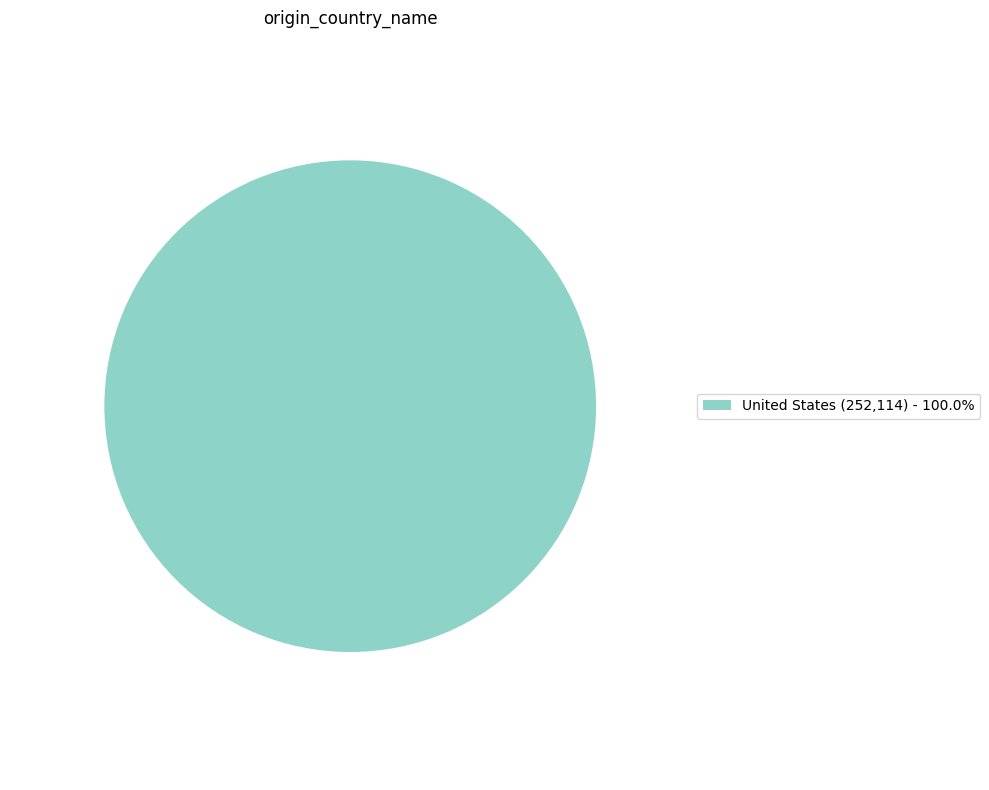

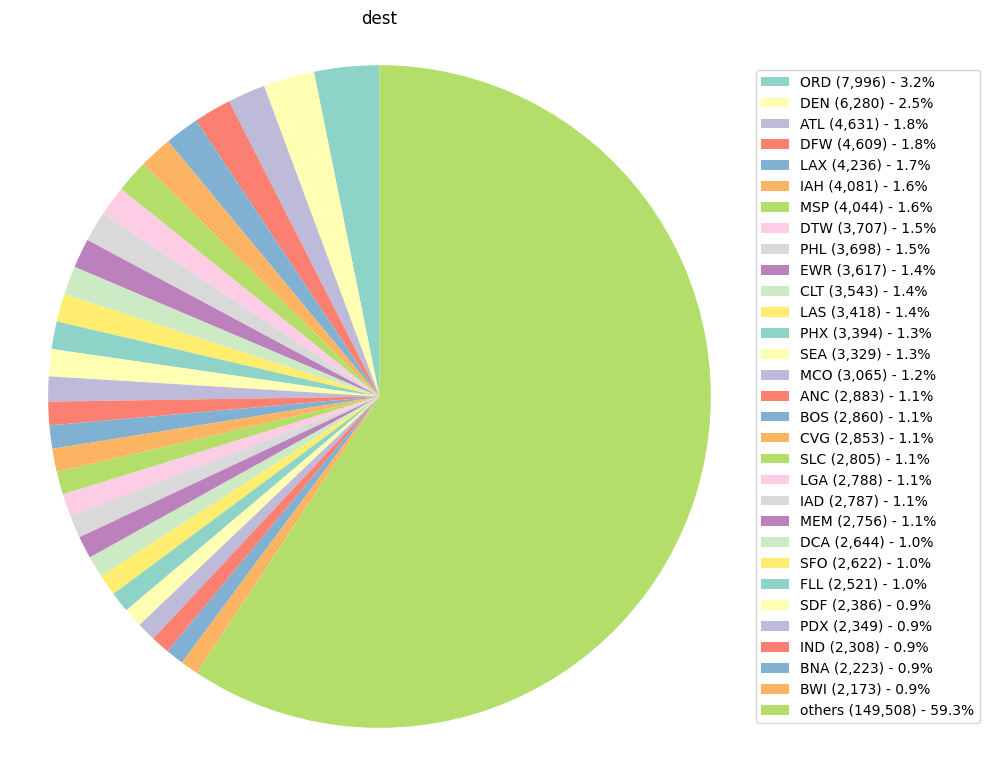

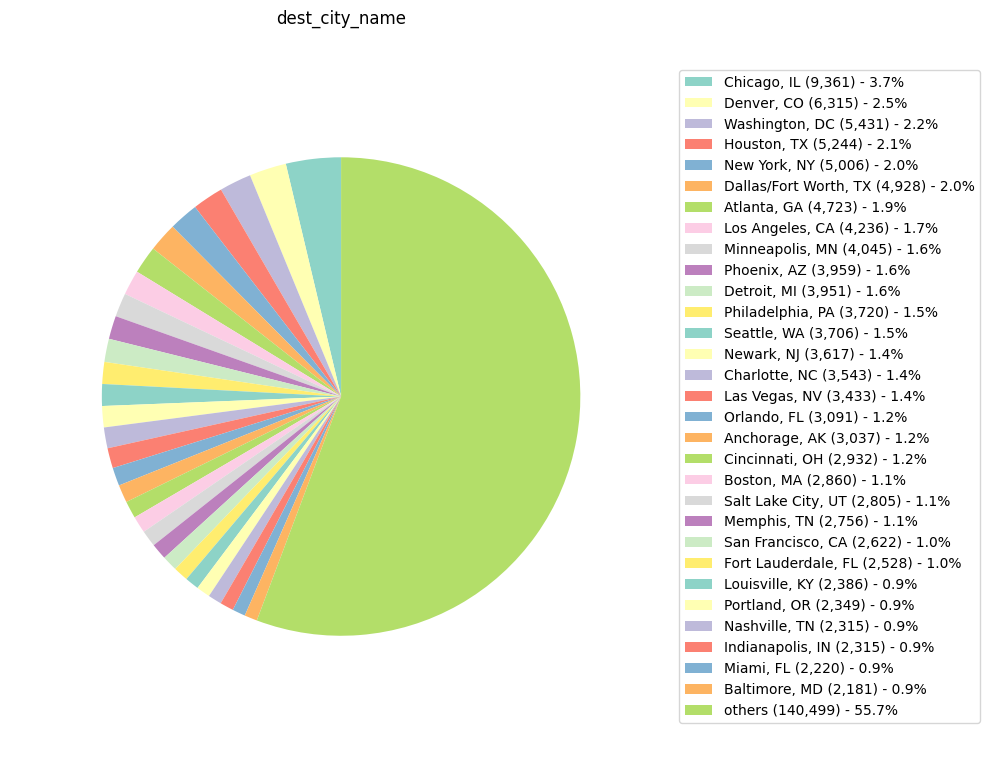

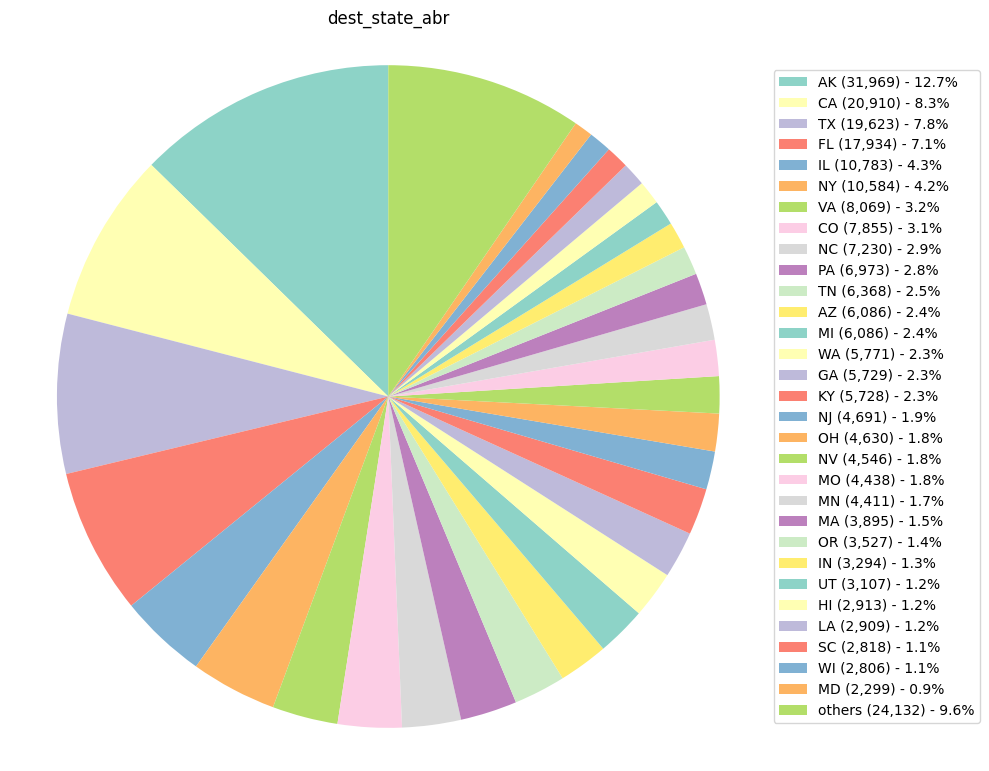

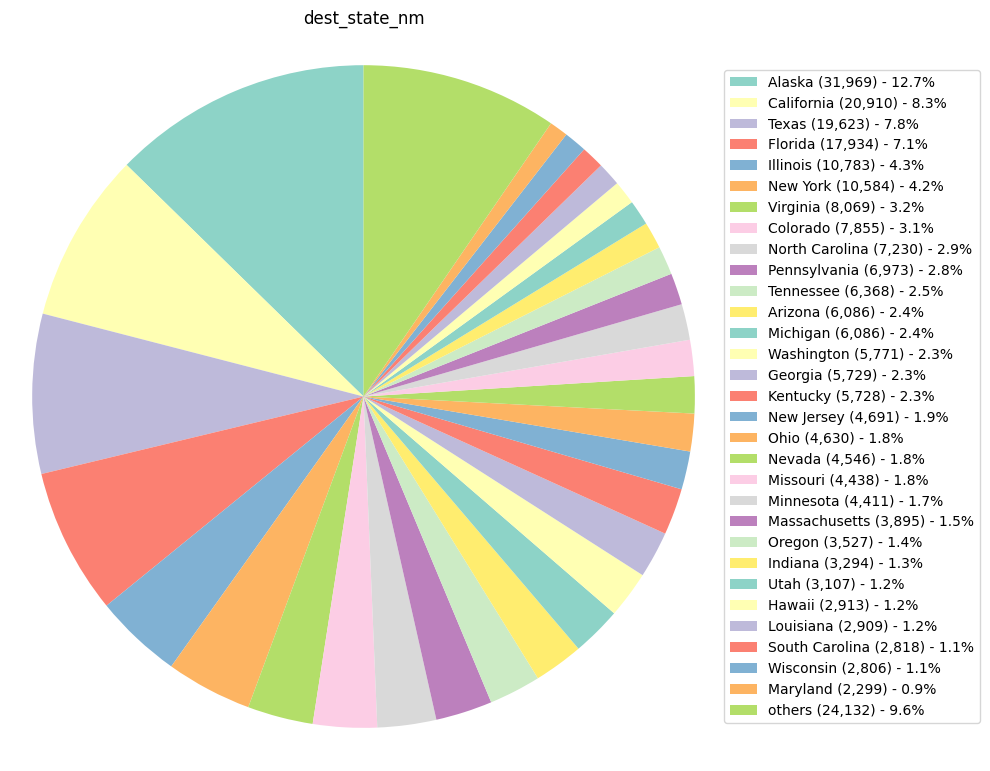

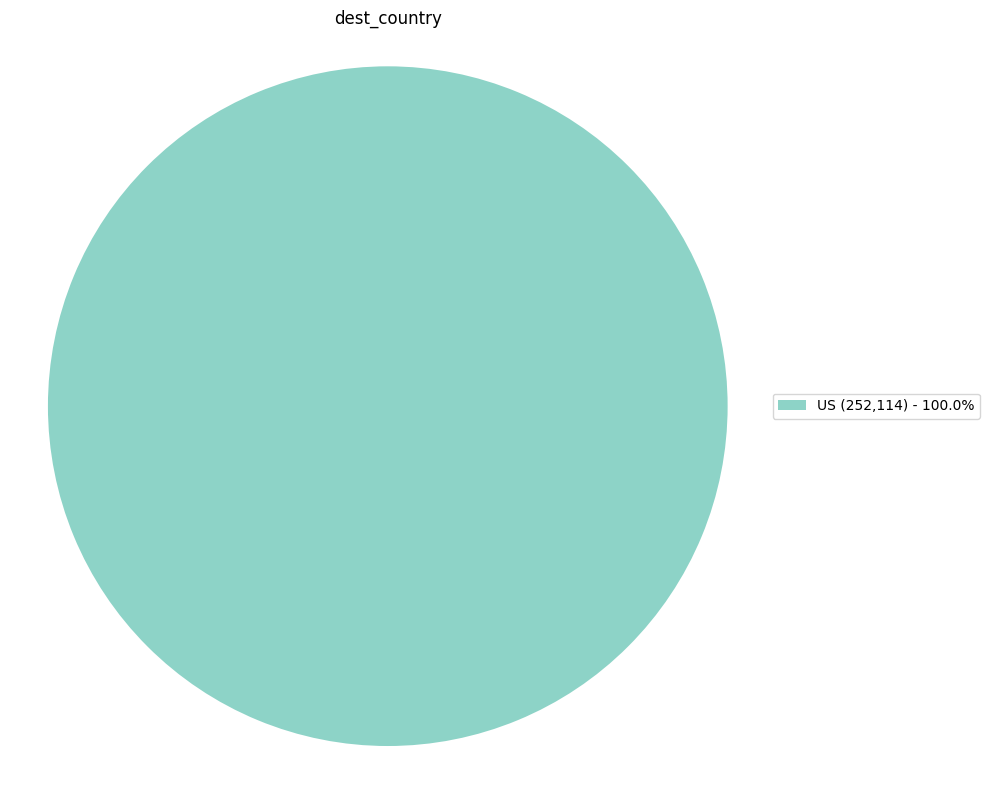

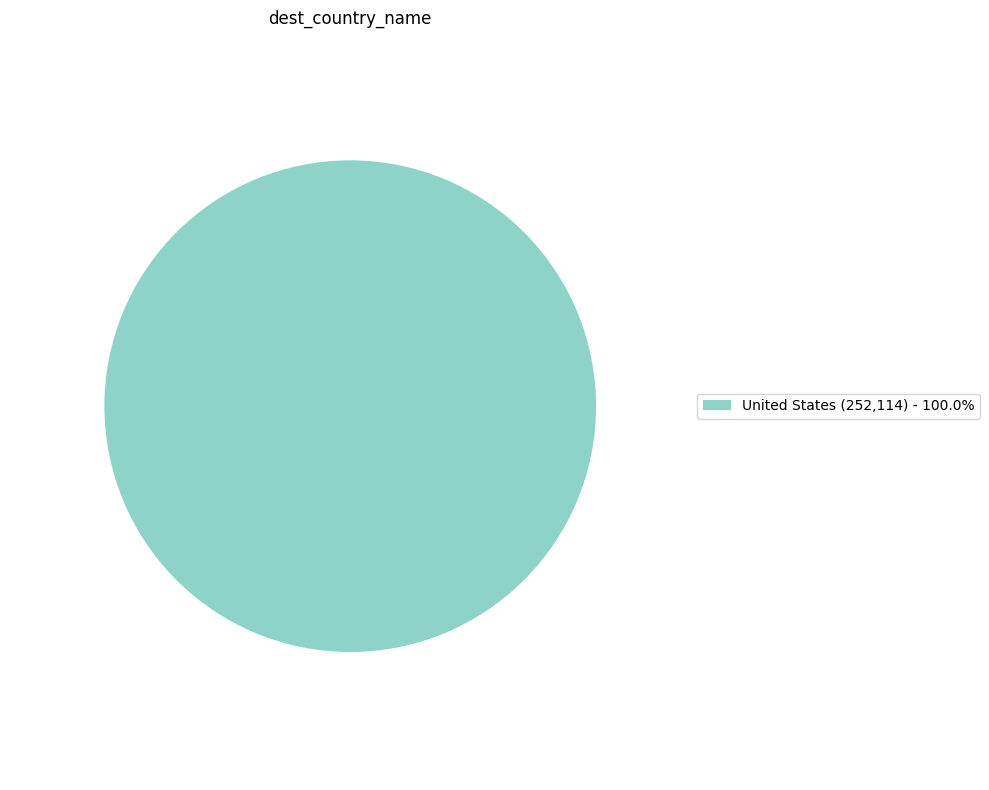

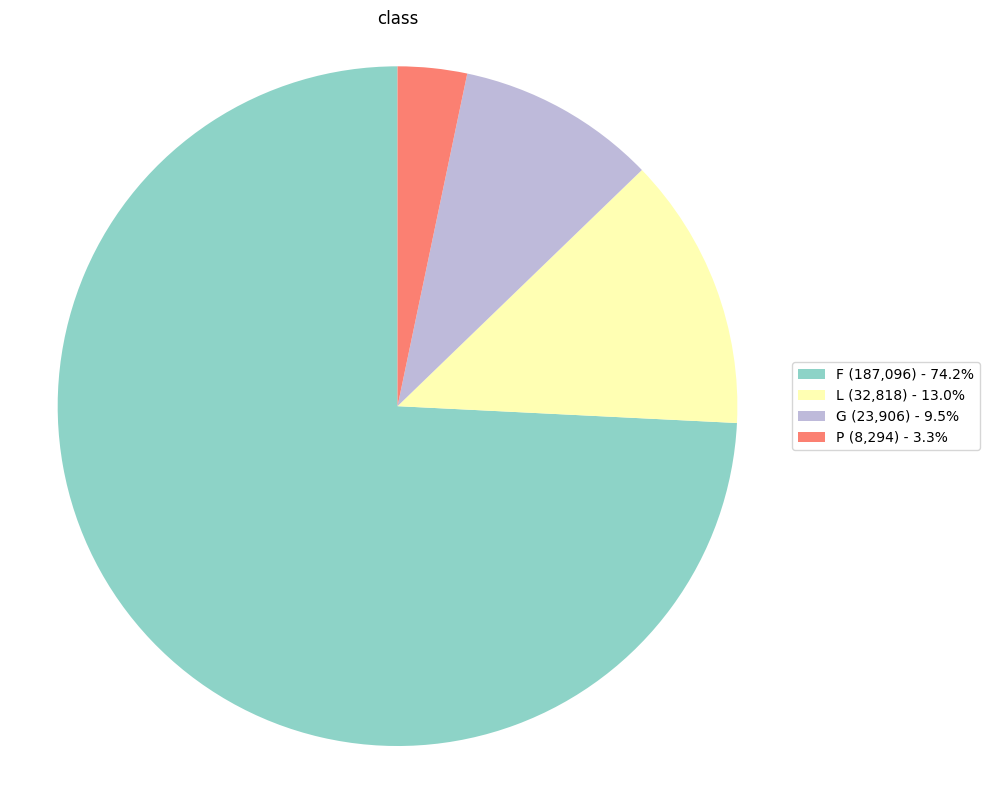

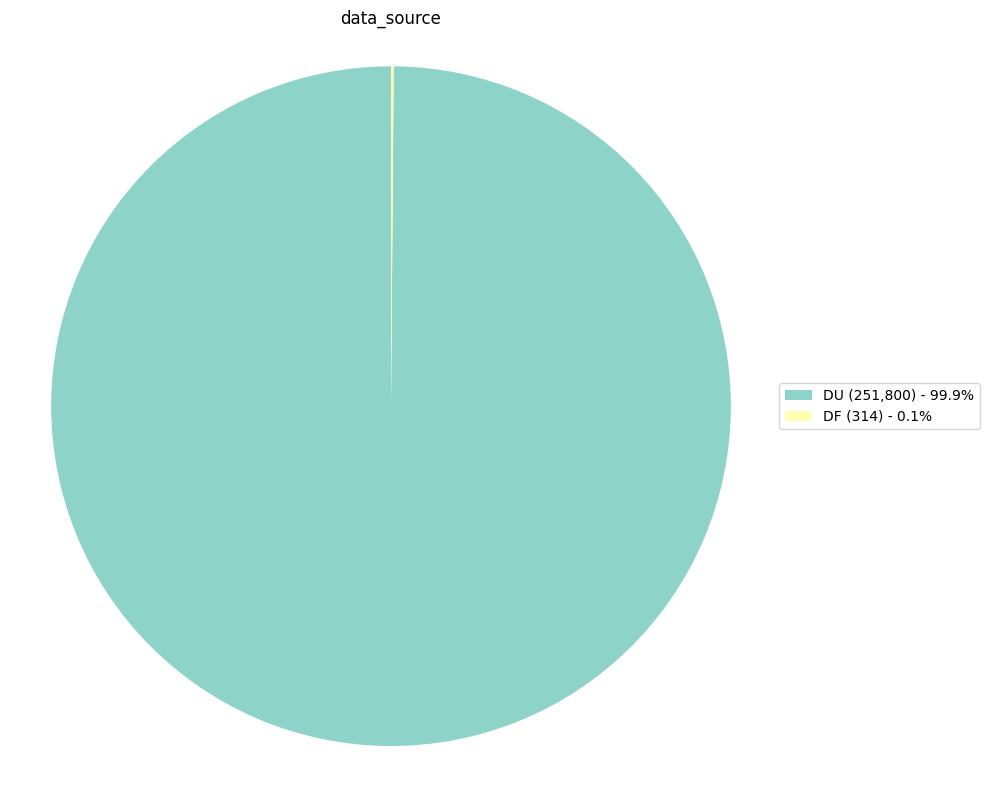

In [22]:
for feature in cat_features:
    plt.figure(figsize=(10, 8))
    max_cats = 30
    value_counts = df_cat[feature].value_counts()[:max_cats]
    if max_cats < len(df_cat[feature].value_counts()):
        value_counts = pd.concat([value_counts, pd.Series({"others" : df_cat[feature].value_counts()[max_cats:].sum()})])
    percentages = value_counts / value_counts.sum() * 100

    patches, texts = plt.pie(value_counts.values, 
        labels=None, startangle=90, colors=plt.cm.Set3.colors)
    
    plt.legend(patches, 
        [f'{label} ({count:,}) - {pct:.1f}%' for label, count, pct in \
            zip(value_counts.index, value_counts.values, percentages)],
        loc="center left", bbox_to_anchor=(1, 0, 0.5, 1))
    
    plt.title(feature)
    plt.axis('equal')
    plt.tight_layout()
    plt.show()

## Шаг 3. One-hot-encoding

Примените one-hot кодирование для ваших категориальных признаков.
Подсказка: используйте `pandas.get_dummies(...)`.

**ВАЖНО**: не перезаписывайте `df_cat`, запишите результат в переменную `df_ohe`

In [23]:
df_ohe = pd.get_dummies(df_cat)
df_ohe.head()

,unique_carrier_04Q,unique_carrier_09Q,unique_carrier_0UQ,unique_carrier_0WQ,unique_carrier_13Q,unique_carrier_14Q,unique_carrier_17Q,unique_carrier_1AQ,unique_carrier_1BQ,unique_carrier_1EQ,...,dest_state_nm_Wisconsin,dest_state_nm_Wyoming,dest_country_US,dest_country_name_United States,class_F,class_G,class_L,class_P,data_source_DF,data_source_DU
6,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,True,False,False,False,False,True
7,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,True,False,False,False,False,True
8,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,True,False,False,False,False,True
9,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,True,False,False,False,False,True
11,False,False,False,False,False,False,False,False,False,False,...,False,False,True,True,False,False,False,True,False,True


# Задание 4. Поиск выбросов

В этом задании будем использовать полученные ранее датафреймы `df_standart` и `df_ohe`.

Очистите данные от выбросов, используя метод $3 \sigma$ и `df_standart`. Поскольку числовые данные уже стандартизированы, выбросом будем считать объект $|x| > 3$ (длина объекта больше 3).

Вам необходимо найти выбросы среди `df_standart`, удалить их, если они есть, и удалить соответствующие объекты среди `df_ohe`. Объедините датафреймы и запишите результат в переменную `df_filtered`.

**ВАЖНО**: не перезаписывайте переменные `df_standart` и `df_ohe`. Для промежуточных результатов создавайте другие переменные, например `df_standart_f` и `df_ohe_f`.

In [24]:
mask = (df_standart.abs() <= 3).all(axis=1)
df_standart_f = df_standart.loc[mask]
df_ohe_f = df_ohe.loc[mask]
df_filtered = pd.concat([df_standart_f, df_ohe_f], axis=1)
df_filtered.describe()

,passengers,freight,mail,distance,airline_id,carrier_group,carrier_group_new,origin_airport_id,origin_airport_seq_id,origin_city_market_id,origin_state_fips,origin_wac,dest_airport_id,dest_airport_seq_id,dest_city_market_id,dest_state_fips,dest_wac,quarter,month,distance_group
count,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000,236082.000000
mean,-0.109323,-0.081419,-0.068438,-0.034284,-0.034881,0.004132,-0.007124,-0.001077,-0.001077,0.000405,0.017486,0.000245,-0.001237,-0.001237,-0.000630,0.017522,0.000869,0.000973,0.001385,-0.034309
std,0.604095,0.309157,0.200706,0.918864,0.923639,0.992098,0.980614,0.997766,0.997766,0.999533,0.997717,0.990340,0.998439,0.998439,0.999585,0.997239,0.989535,1.001559,1.002035,0.919771
min,-0.473529,-0.145430,-0.105035,-1.160906,-1.479315,-2.913570,-2.818013,-1.738284,-1.738302,-1.380297,-1.344678,-1.544683,-1.749699,-1.749717,-1.388445,-1.346154,-1.547850,-1.367110,-1.615071,-0.839964
25%,-0.472502,-0.145430,-0.105035,-0.746273,-0.704887,-0.497694,-0.182109,-0.927796,-0.927807,-0.851428,-0.954764,-0.811321,-0.936607,-0.936618,-0.857845,-0.955698,-0.814522,-0.475672,-0.751874,-0.839964
50%,-0.417056,-0.145430,-0.105035,-0.261065,0.233074,0.710243,-0.182109,0.077915,0.077911,-0.239230,-0.007829,-0.177962,0.072335,0.072331,-0.245200,-0.007446,-0.181193,0.415767,0.111323,-0.092986
75%,0.021525,-0.143904,-0.105035,0.409406,0.417282,0.710243,-0.182109,0.840542,0.840551,0.763403,0.883403,0.888747,0.837412,0.837422,0.758165,0.885027,0.885466,1.307206,0.974519,0.653991
max,2.999767,2.999354,2.998868,2.963368,2.977406,0.710243,2.453795,2.588728,2.588713,2.995136,2.944379,1.522105,2.591215,2.591200,2.999597,2.948870,1.518795,1.307206,1.549984,2.894924


### Дополнительное задание **.  Расстояния от центроида кластера
**ВАЖНО**: Дополнительное задание не является обязательным к выполнению, но позволяет получить дополнительные баллы по курсу.

В рамках этого дополнительного задания попробуйте найти выбросы через расстояния до центроидов кластеров. Для этого выполните кластеризацию датасета.
Затем, чтобы найти выбросы, постройте для каждого кластера распределение расстояний до центроида. Выбросы отсекайте по перцентилям (значения выберите на ваше усмотрение).

Замечание: для этого задания вы можете использовать библиотку scikit-learn.

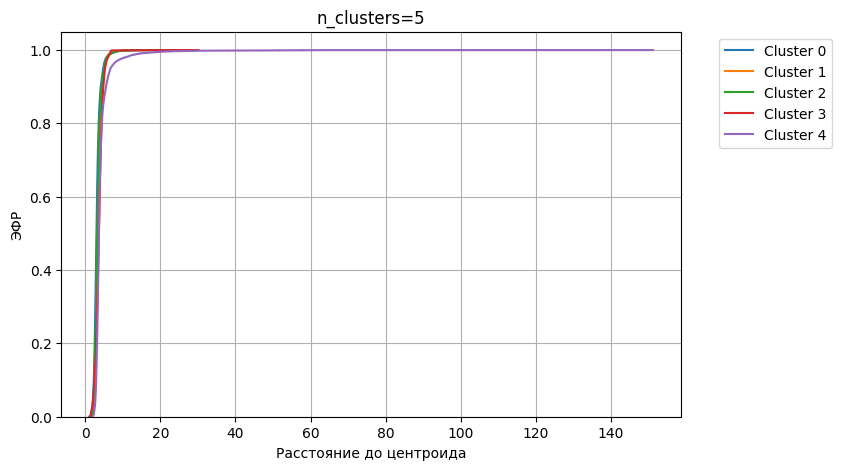

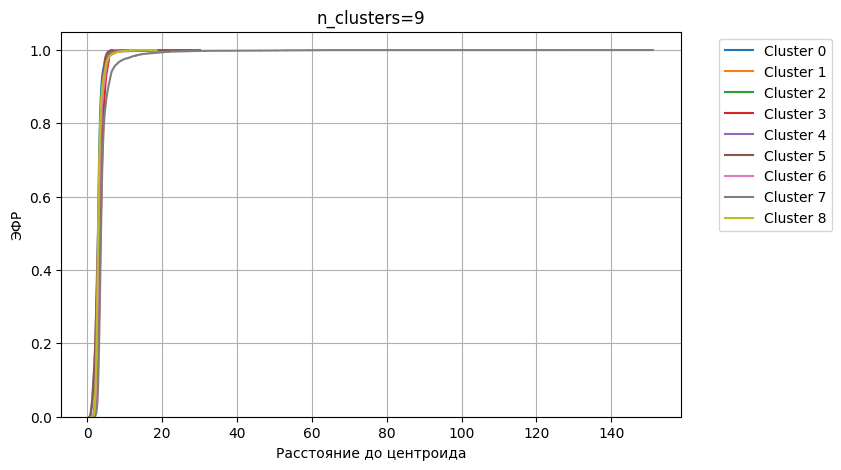

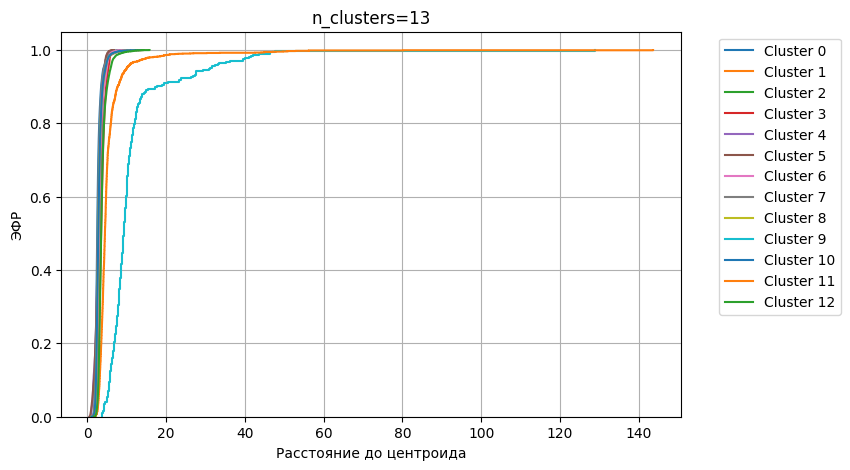

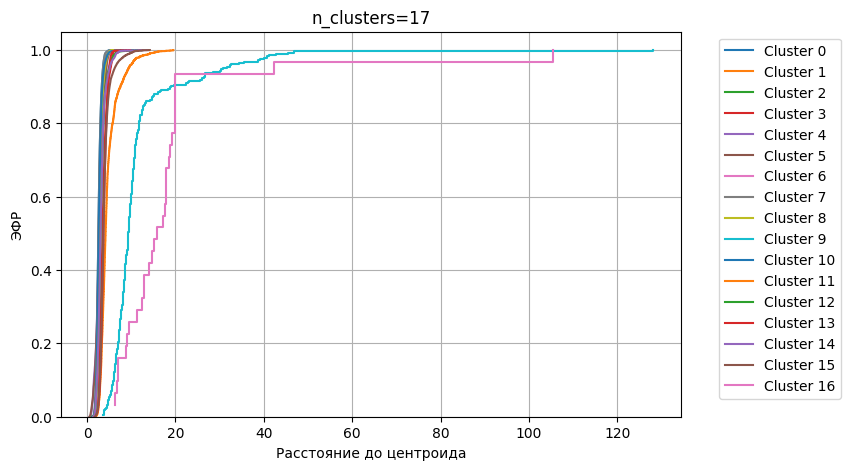

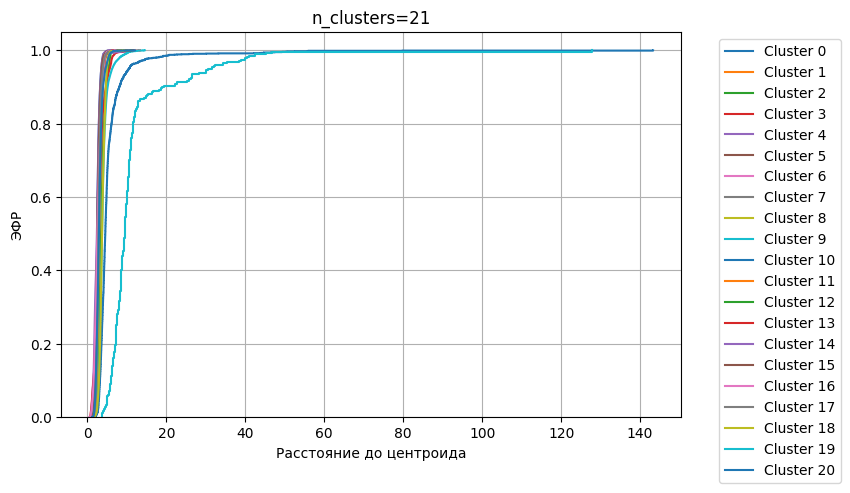

In [25]:
def k_means_test(n, quantile):
    kmeans = KMeans(n_clusters=n, random_state=17)
    labels = kmeans.fit_predict(df_standart)

    distances = np.linalg.norm(df_standart - kmeans.cluster_centers_[labels], axis=1)
    df_dist = pd.DataFrame({'cluster': labels, 'distance': distances})

    thresholds = (df_dist.groupby('cluster')['distance'].quantile(quantile))
    return df_dist.apply(lambda row: row['distance'] <= thresholds[row['cluster']], axis=1), df_dist

def plot_ecdf(df_dist, n, quantile=0.9):
    plt.figure(figsize=(8, 5))
    
    for cluster in sorted(df_dist['cluster'].unique()):
        distances = df_dist.loc[df_dist['cluster'] == cluster, 'distance']
        x = np.sort(distances)
        y = np.arange(1, len(x)+1) / len(x)
        plt.step(x, y, where='post', label=f'Cluster {cluster}')
    
    plt.title(f"n_clusters={n}")
    plt.xlabel("Расстояние до центроида")
    plt.ylabel("ЭФР")
    plt.ylim([0, 1.05])
    plt.legend(loc='upper left', bbox_to_anchor=(1.05, 1))
    plt.grid(True)
    plt.show()

for n in [5, 9, 13, 17, 21]:
    _, df_dist = k_means_test(n, quantile=0.9)
    plot_ecdf(df_dist, n, quantile=0.9)

Выберем $n=13$ и перцентиль 0.9

In [26]:
mask, _ = k_means_test(13, quantile=0.9)
df_standart_filtered = df_standart.loc[mask.values]
df_ohe_filtered = df_ohe.loc[mask.values]
df_filtered_kmeans = pd.concat([df_standart_filtered, df_ohe_filtered], axis=1)

df_filtered_kmeans.describe()

,passengers,freight,mail,distance,airline_id,carrier_group,carrier_group_new,origin_airport_id,origin_airport_seq_id,origin_city_market_id,origin_state_fips,origin_wac,dest_airport_id,dest_airport_seq_id,dest_city_market_id,dest_state_fips,dest_wac,quarter,month,distance_group
count,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000,226898.000000
mean,-0.108674,-0.024659,-0.046824,-0.029175,-0.055401,0.047522,0.033192,-0.016988,-0.016988,-0.017061,0.000267,0.014044,-0.009307,-0.009307,-0.008938,-0.000143,0.013842,-0.000895,-0.000749,-0.031509
std,0.606726,0.732344,0.656352,0.939456,0.899849,0.965124,0.942761,0.976775,0.976775,0.968018,0.967321,0.978600,0.980733,0.980733,0.977133,0.967413,0.978332,0.995231,0.994804,0.939242
min,-0.473529,-0.145430,-0.105035,-1.160906,-1.479315,-1.705632,-1.939378,-1.738284,-1.738302,-1.380297,-1.344678,-1.544683,-1.749699,-1.749717,-1.388445,-1.346154,-1.547850,-1.367110,-1.615071,-0.839964
25%,-0.472355,-0.145430,-0.105035,-0.743333,-0.704887,-0.497694,-0.182109,-0.927796,-0.927807,-0.811108,-0.954764,-0.811321,-0.936607,-0.936618,-0.817495,-0.955698,-0.814522,-0.475672,-0.751874,-0.839964
50%,-0.408549,-0.145430,-0.105035,-0.261065,0.233074,0.710243,-0.182109,0.077915,0.077911,-0.239230,-0.007829,-0.144628,0.072335,0.072331,-0.245200,-0.007446,-0.147860,0.415767,0.111323,-0.092986
75%,0.026219,-0.143813,-0.105035,0.387351,0.409764,0.710243,-0.182109,0.829206,0.829197,0.763403,0.883403,0.888747,0.837412,0.837422,0.758165,0.885027,0.885466,1.307206,0.974519,0.653991
max,11.600058,18.697060,32.968662,5.283548,3.353342,0.710243,5.089700,2.588728,2.588713,3.210178,2.944379,1.522105,2.586792,2.586777,3.206726,2.948870,1.518795,1.307206,1.549984,5.135857
